##Steps to follow

1.Exploring, understanding, and visualizing the data.

2.Preparing the data for modeling (train-test split, rescaling, etc.).

3.Training and tuning the model.

4.Diagnostic residual analysis.

5.Predicting and evaluating on the test set.

***Importing libraries***

In [1]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing & Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Feature Selection
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Statistical Modeling & Diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Model Evaluation
from sklearn.metrics import r2_score

# Environment Configuration
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Machine Learning Model
from sklearn.ensemble import RandomForestRegressor

# Cross-Validation & Model Selection
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score

# Performance Metrics
from sklearn import metrics
from sklearn.metrics import mean_squared_error

# Example Datasets (Optional/Testing)
from sklearn import datasets

In [3]:
# Notebook Environment Settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Step 1:- Reading and understanding the data

In [5]:
# Load and inspect dataset
df_car = pd.read_csv('/content/CarPrice_Assignment.csv')
df_car.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
# Check dataset dimensions (rows, columns)
df_car.shape

(205, 26)

In [7]:
# Display dataset summary (data types, missing values, memory usage)
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
# Generate descriptive statistics for numerical columns
df_car.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### Spliting the "Car company" from "CarName"

In [9]:
# Extract the car company name and drop the raw CarName column
df_car['CarCompany'] = df_car['CarName'].str.split(' ', n=1, expand=True)[0]
df_car.drop('CarName', axis=1, inplace=True)

# Preview the updated dataset
df_car.head()

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [10]:
# Drop unique identifier column (not useful for predictive modeling)
df_car.drop('car_ID', axis=1, inplace=True)

### Handaling missing values in columns

In [11]:
# Check for missing values across all columns
df_car.isnull().sum()

,0
symboling,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0
carlength,0
carwidth,0


***Observations***

The dataset contains zero missing values across all rows and columns.

### Cleaning data
# Fix spelling inconsistencies and typos in categorical column values

In [12]:
# Map typo replacements for CarCompany and drivewheel columns
company_corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'Nissan': 'nissan'
}

# Apply corrections
df_car['CarCompany'] = df_car['CarCompany'].replace(company_corrections)
df_car['drivewheel'] = df_car['drivewheel'].replace({'4wd': 'fwd'})

### Handling outliers

In [13]:
# Numerical columns to evaluate for outliers
col_numeric = [
    'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
    'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
    'peakrpm', 'citympg', 'highwaympg', 'price'
]

# Sequentially filter out records outside 1.5 * IQR boundaries
for col in col_numeric:
    q1 = df_car[col].quantile(0.25)
    q3 = df_car[col].quantile(0.75)
    iqr = q3 - q1

    range_low = q1 - 1.5 * iqr
    range_high = q3 + 1.5 * iqr

    # Update dataframe by keeping only rows within the acceptable range
    df_car = df_car[(df_car[col] >= range_low) & (df_car[col] <= range_high)]

# Verify the final dataset dimensions
df_car.shape

(125, 25)

Outlier filtering using the 1.5 IQR rule removed 82 anomaly records from the dataset, reducing the sample size from 205 to 123 rows.

### Checking Data Imbalance

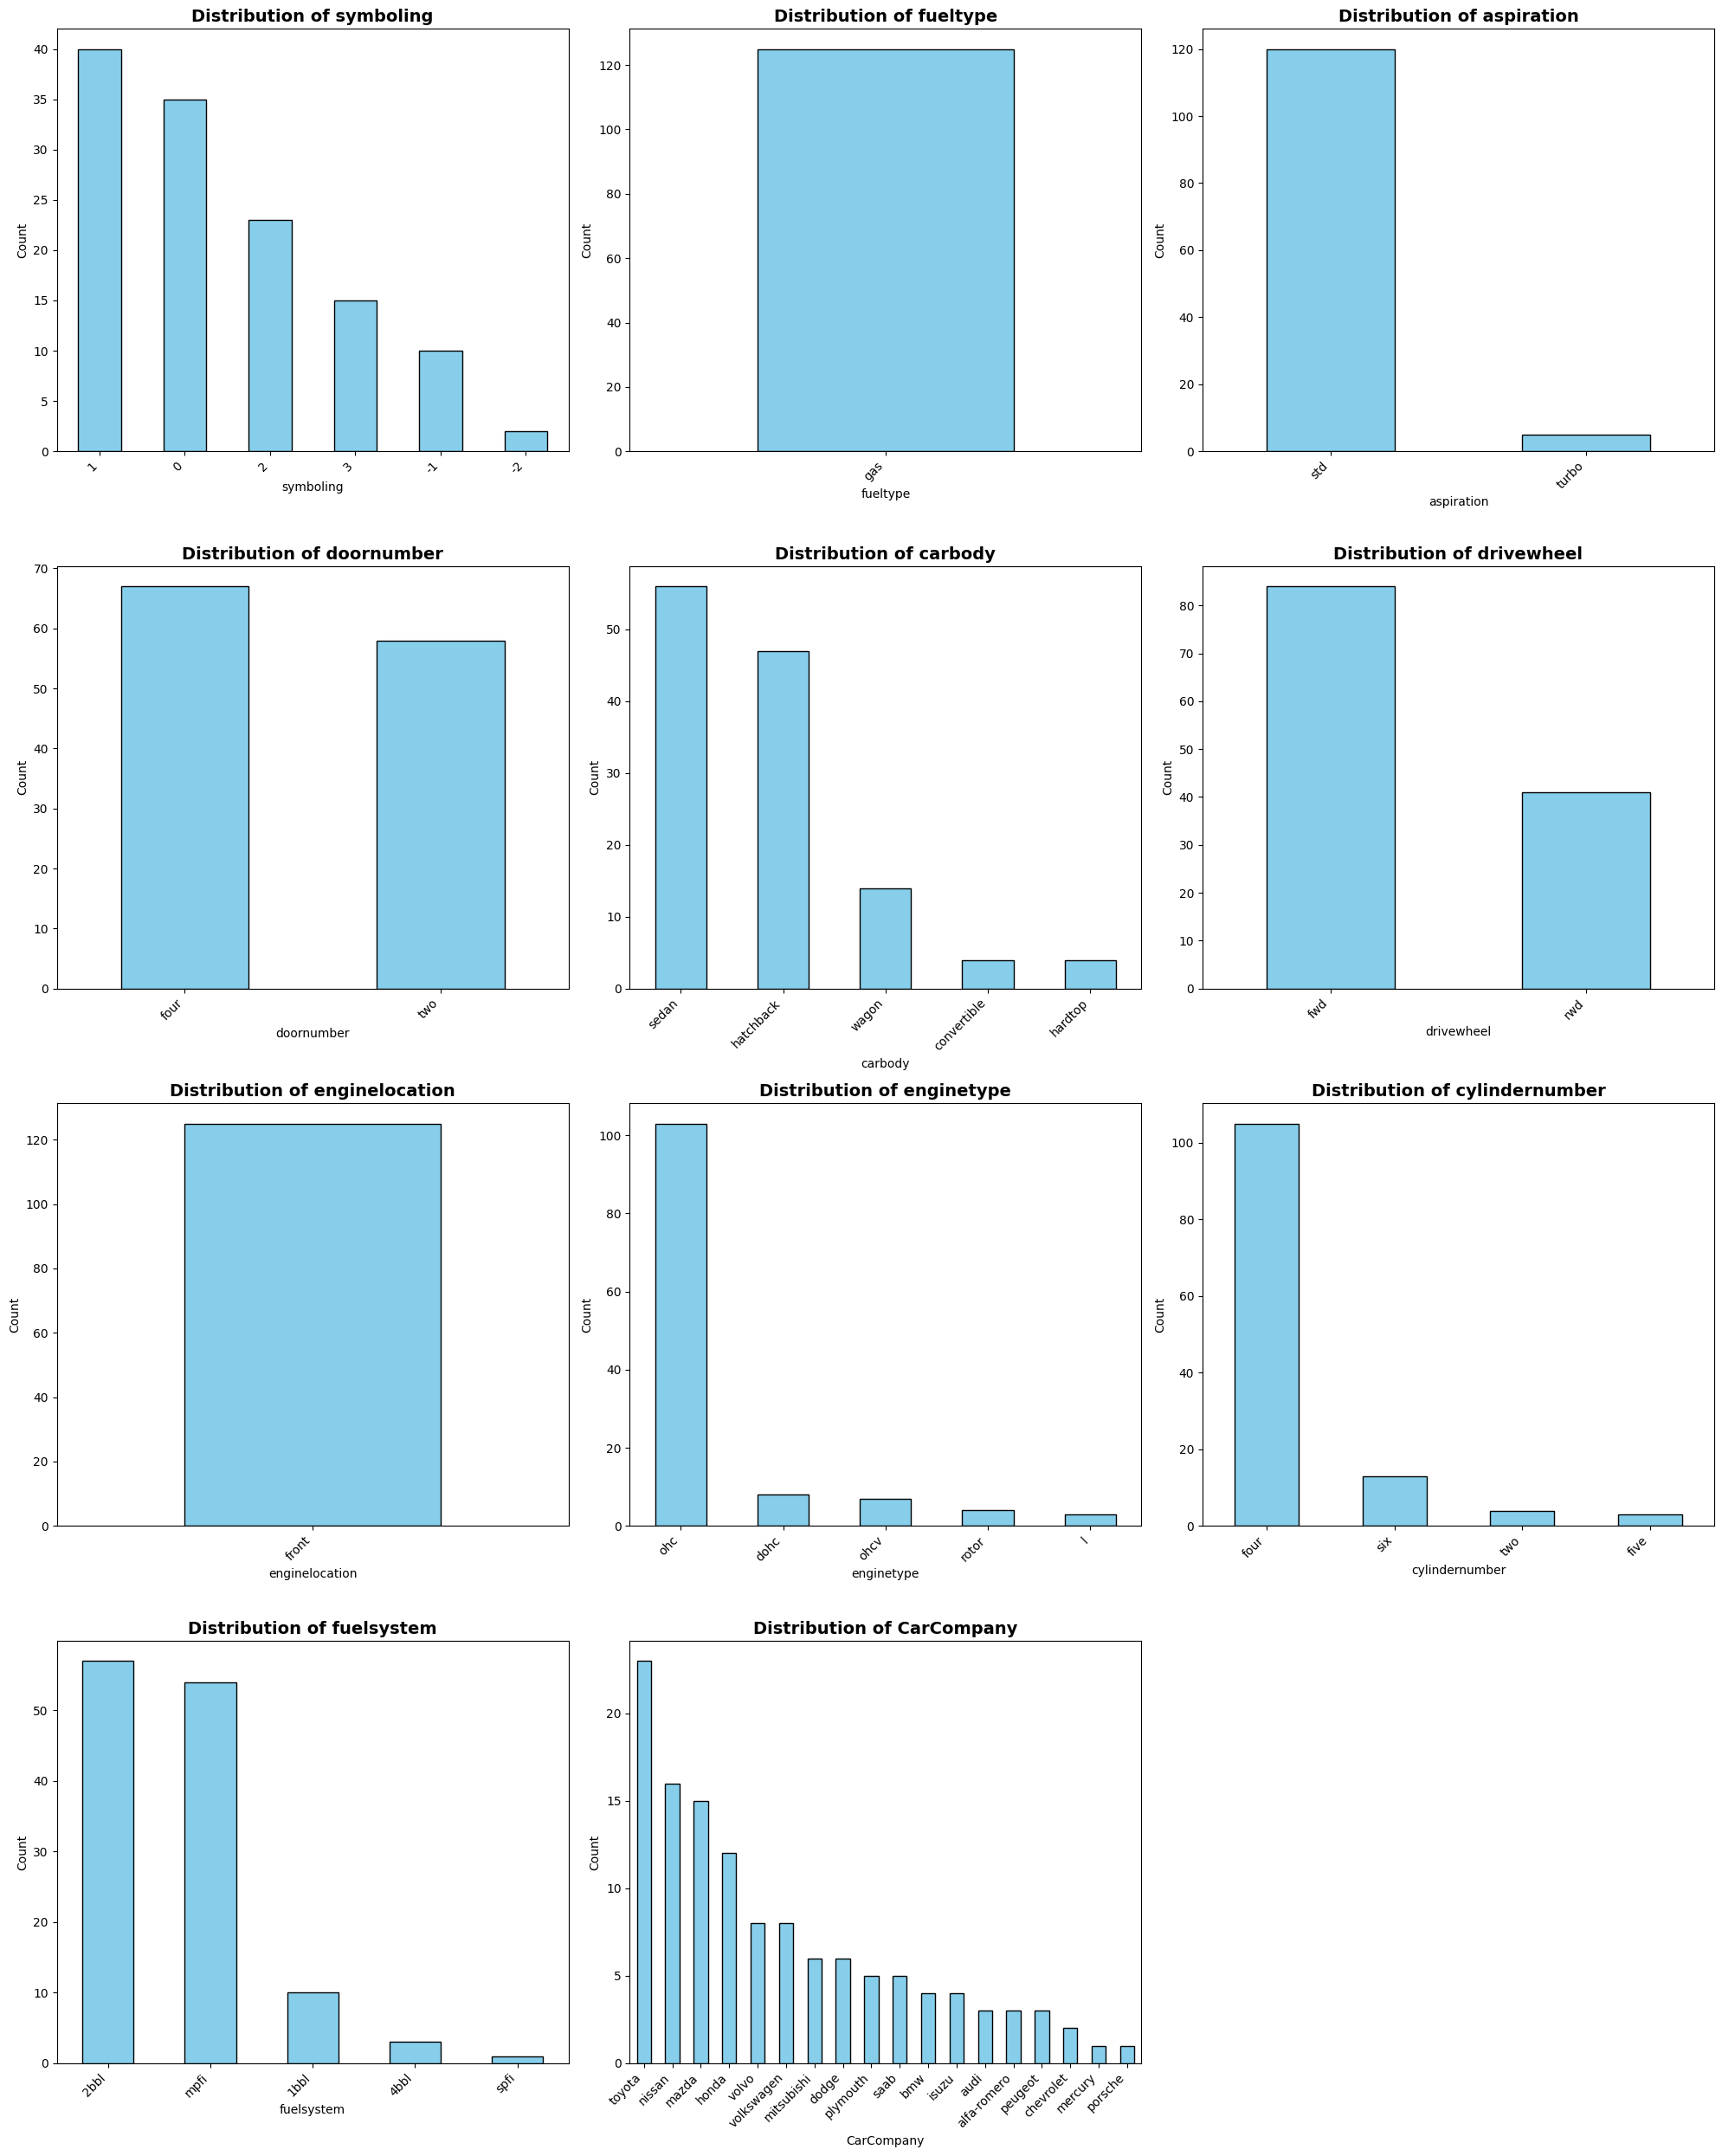

In [14]:
# List of categorical columns to analyze for data imbalance
col_category = [
    'symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
    'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
    'fuelsystem', 'CarCompany'
]

# Set up the plotting grid (4 rows, 3 columns)
plt.figure(figsize=(20, 25))

for k, col in enumerate(col_category, start=1):
    plt.subplot(4, 3, k)
    df_car[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')

# Adjust layout to prevent overlapping labels and titles
plt.tight_layout()

#Key Observations on Data Imbalance
A look at the categorical feature distributions reveals significant class imbalances across several variables:

1. symboling: The data is heavily skewed toward mid-range risk ratings, with almost no representation for the -2 safety rating.

2. fueltype: The dataset now consists exclusively of gas-powered vehicles; all diesel records were eliminated during the outlier removal phase.

3. aspiration: Standard (std) engines heavily outnumber turbochargers.

4. enginelocation: The feature has zero variance now. All rear-engine models were stripped away as outliers, leaving only front-engine configurations.

5. enginetype: Overhead Cam (ohc) engines strongly dominate the dataset compared to all other engine structural designs.

6. cylindernumber: Four-cylinder engines comprise the vast majority of the samples.

7. fuelsystem: Multi-Port Fuel Injection (mpfi) and 2-barrel carburetors (2bbl) are disproportionately more common than alternative fuel delivery systems.

8. CarCompany: The dataset exhibits a strong brand bias, with Toyota vehicles being the most highly represented by a wide margin.

### Visualising the data to check the possiblity of linear regression model

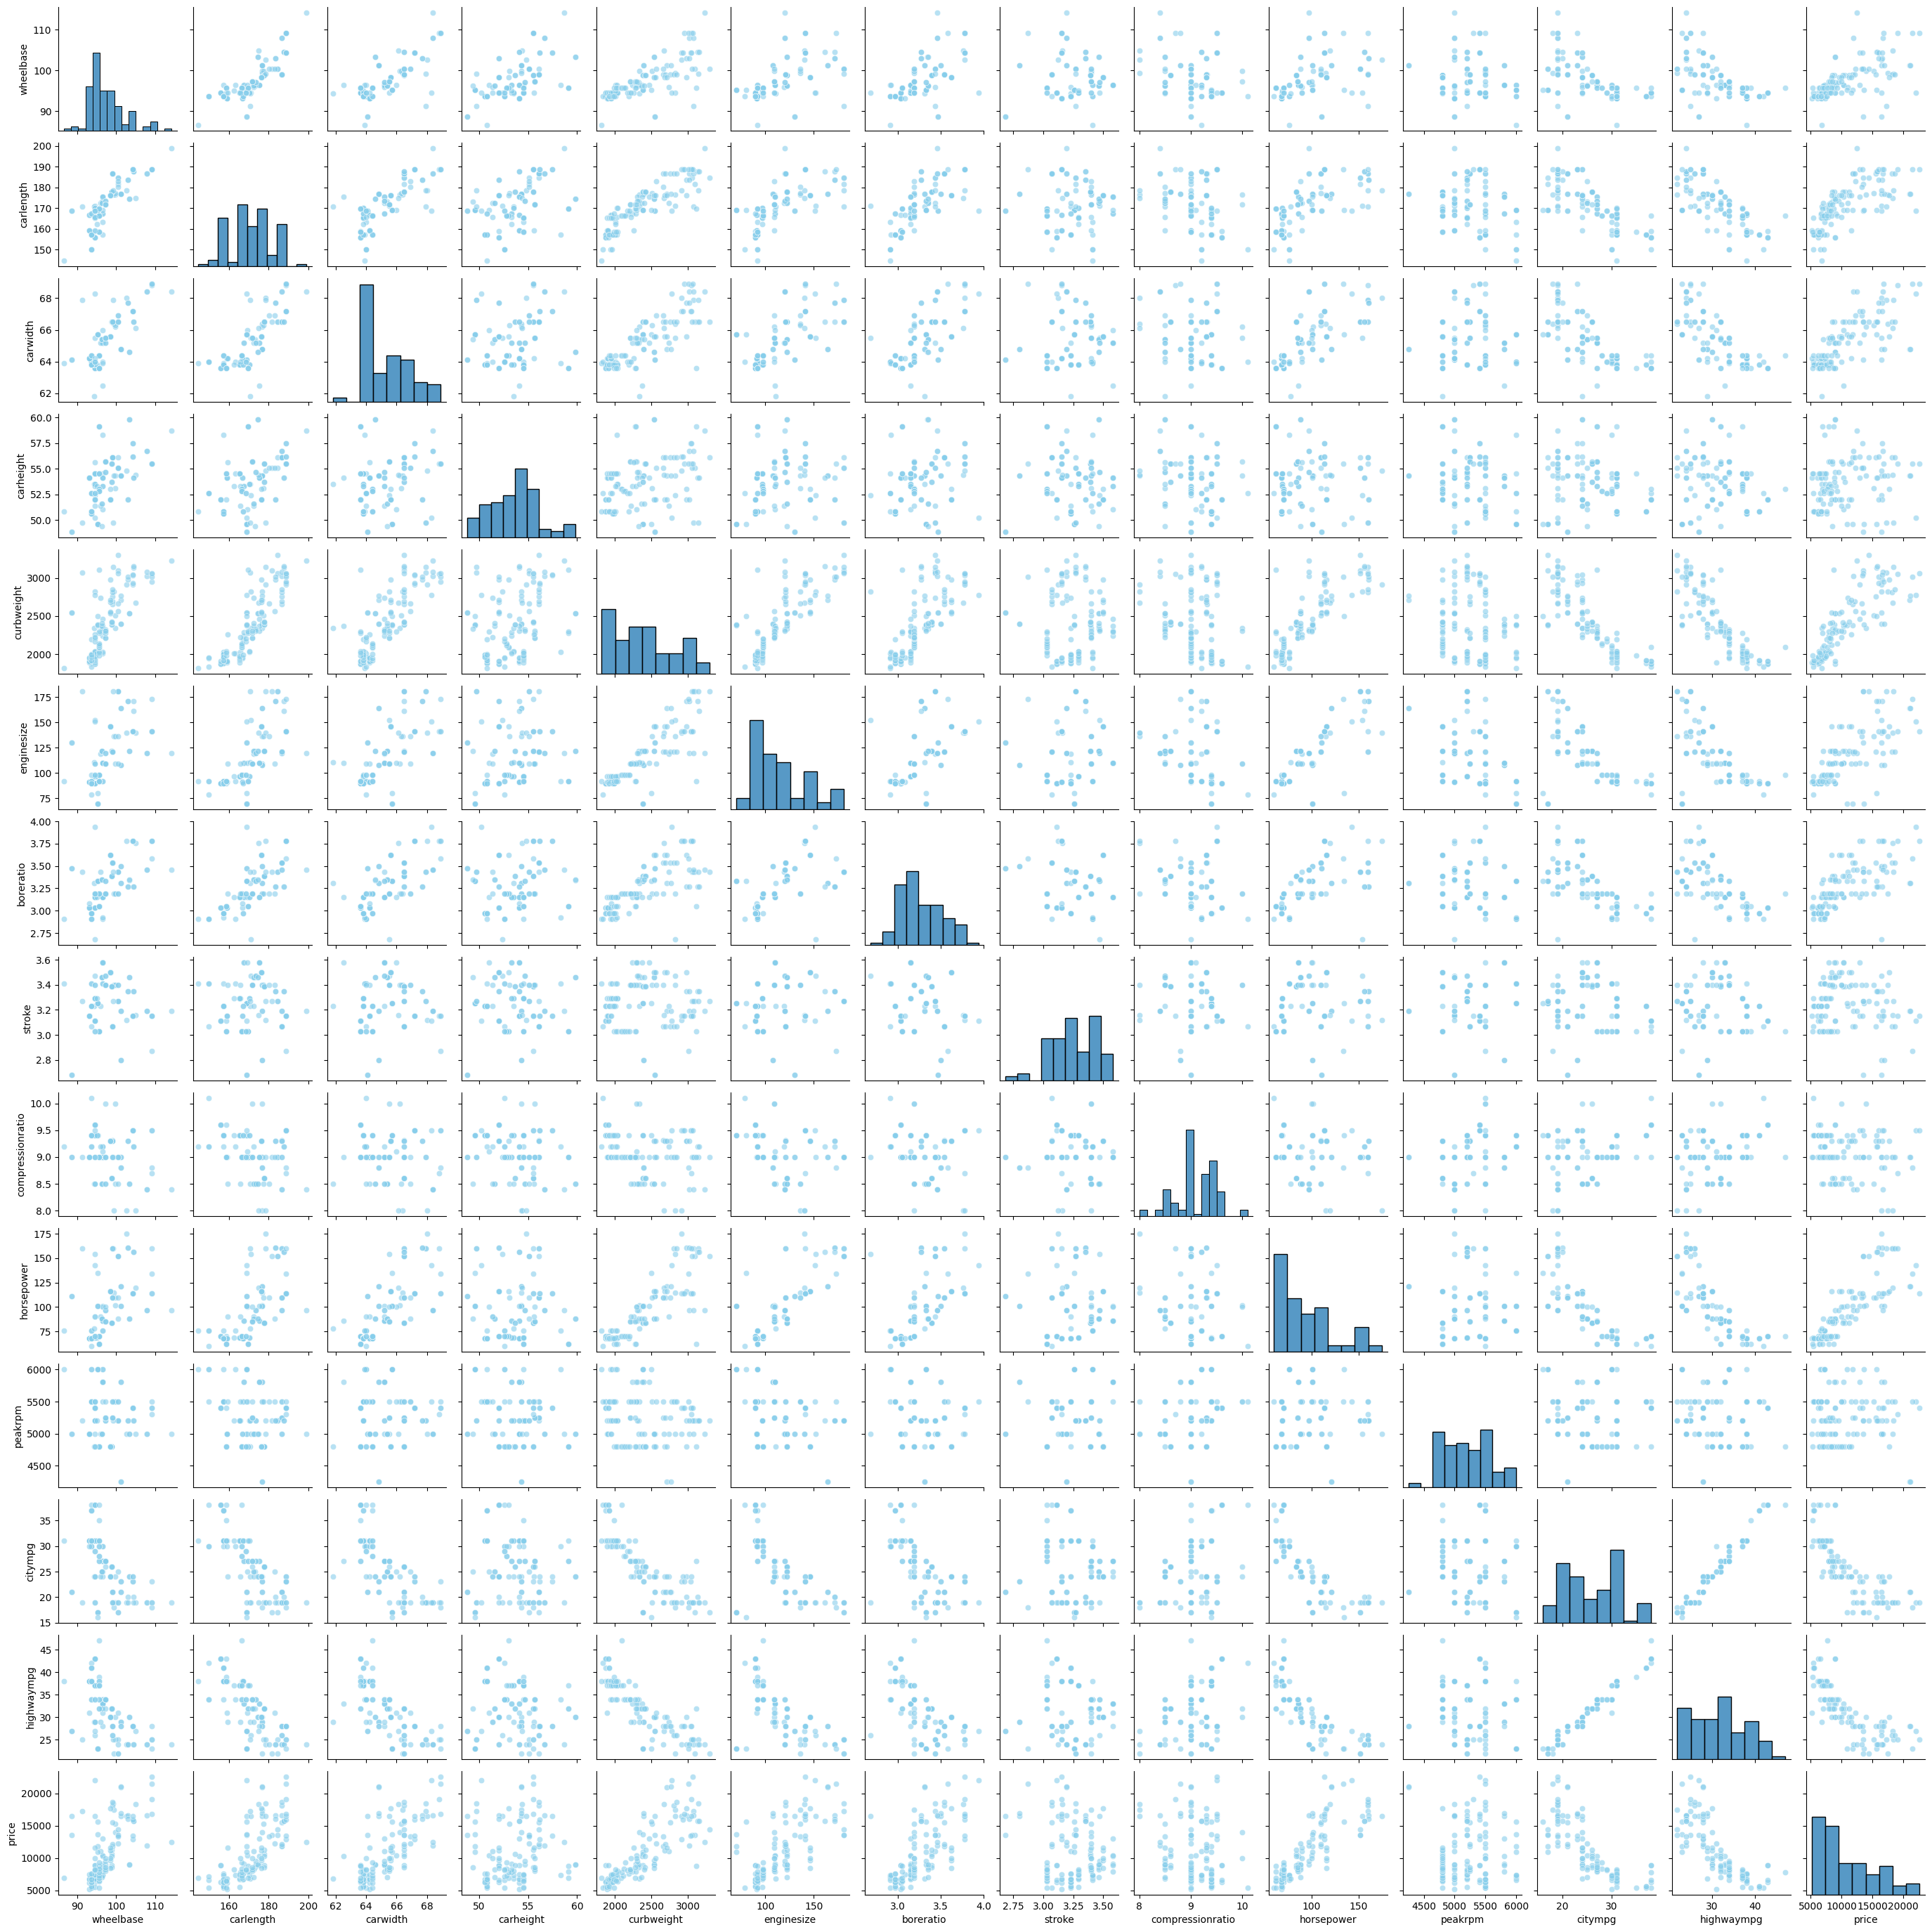

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing relationships between numerical variables
pair_plot = sns.pairplot(
    df_car[col_numeric],
    height=2.0,
    aspect=1.0,
    plot_kws={'alpha': 0.6, 'color': 'skyblue'}
)

# Display the plot in your notebook or IDE execution screen
plt.show()

Several numerical features exhibit a strong linear correlation with the target variable (price). This clear linear trend confirms that the dataset is well-suited for a Linear Regression modeling approach.

### Visualising the categorical variables

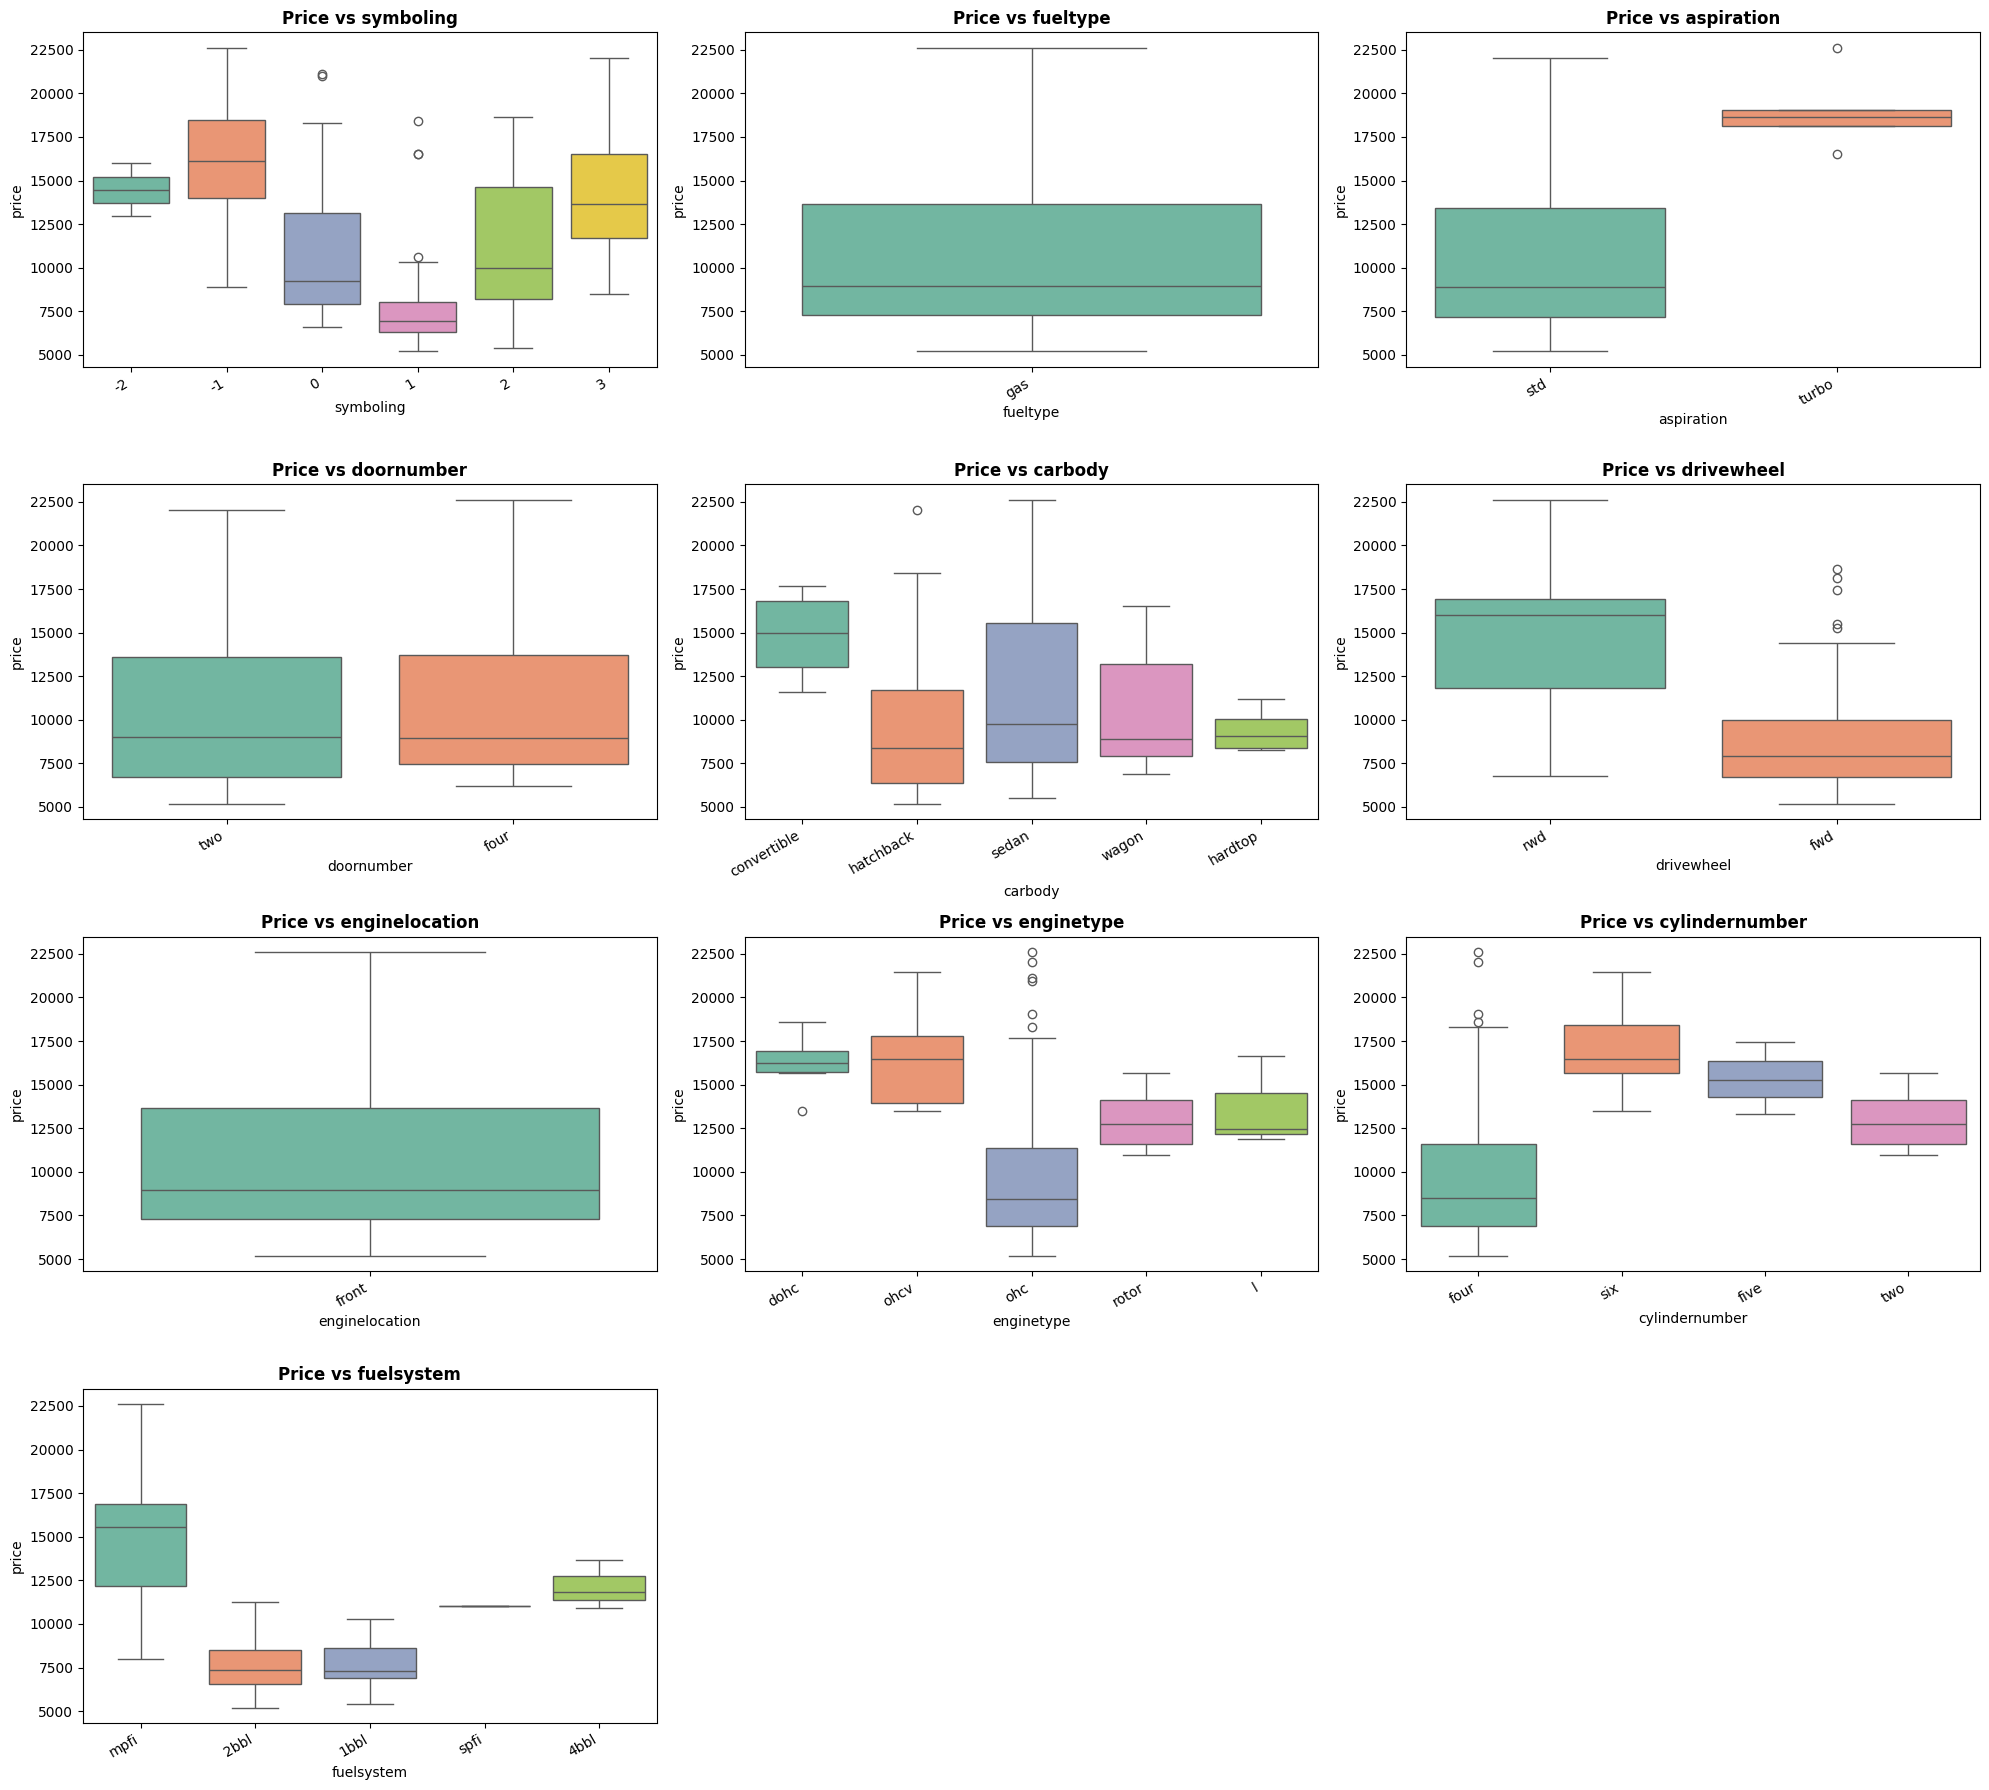

In [17]:
# Box plots for categorical variables against 'price' (excluding CarCompany)
plt.figure(figsize=(20, 18))

# Slice col_category to exclude the last item ('CarCompany')
for k, col in enumerate(col_category[:-1], start=1):
    plt.subplot(4, 3, k)
    sns.boxplot(x=col, y='price', data=df_car, palette='Set2')
    plt.title(f'Price vs {col}', fontsize=12, weight='bold')
    plt.xticks(rotation=30, ha='right')

# Adjust layout to prevent overlapping axis labels and titles
plt.tight_layout()
plt.show()

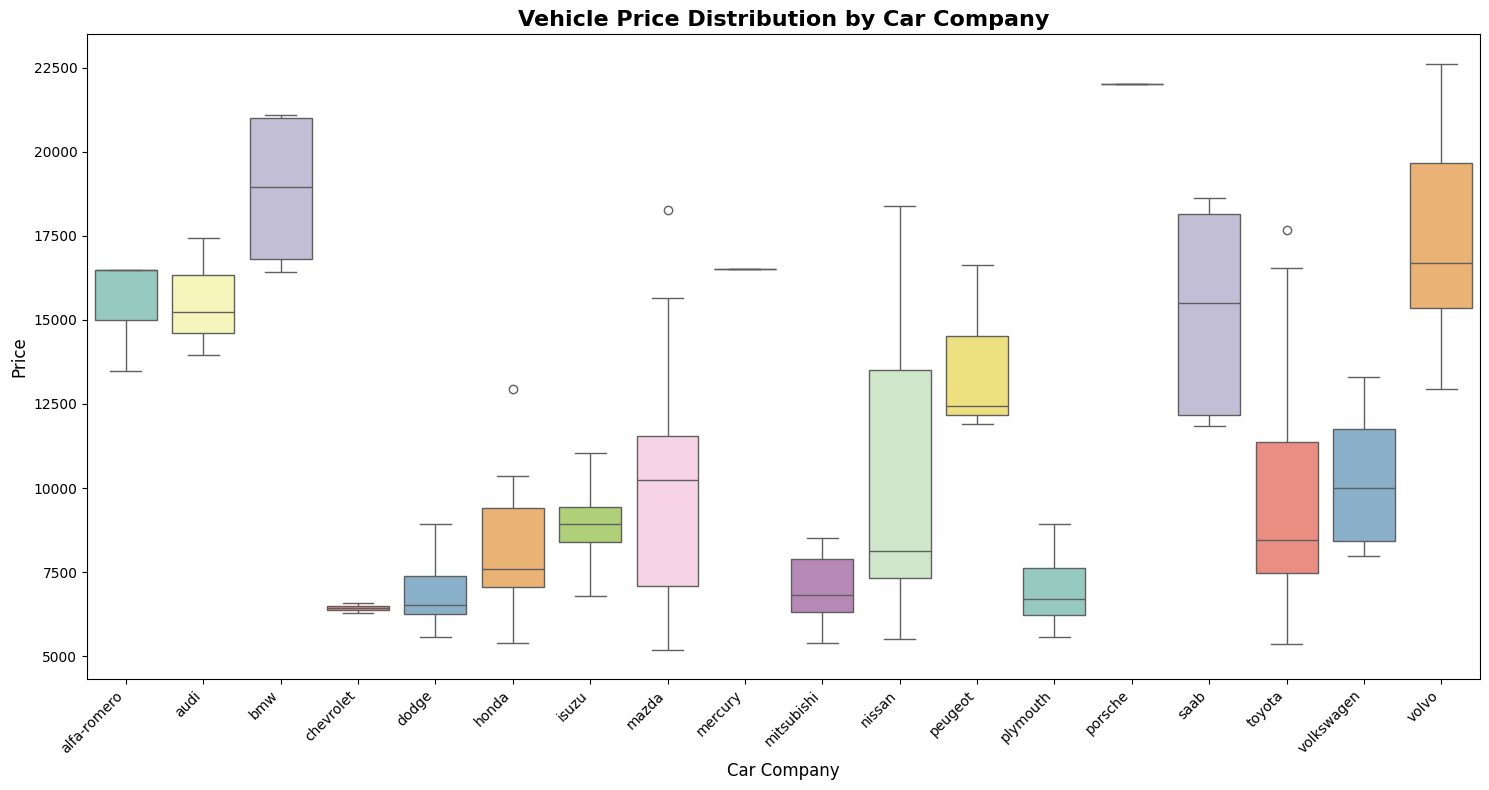

In [18]:
# Detailed boxplot for CarCompany vs Price with expanded figure dimensions
plt.figure(figsize=(15, 8))

sns.boxplot(x='CarCompany', y='price', data=df_car, palette='Set3')
plt.title('Vehicle Price Distribution by Car Company', fontsize=16, weight='bold')
plt.xlabel('Car Company', fontsize=12)
plt.ylabel('Price', fontsize=12)

# Rotate labels to ensure readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##Key Observations from Categorical Box Plots
An analysis of vehicle price distributions across different categories reveals several distinct trends:

1. CarCompany: Porsche exhibits an exceptionally high median price despite having a very low market representation in this sample. High-end brands like BMW, Audi, Volvo, and Alfa Romeo also show significantly higher median prices than mass-market brands. Saab stands out with a notably wide pricing variance alongside a high median cost.

2. aspiration: Vehicles equipped with turbochargers (turbo) maintain a noticeably higher median price than naturally aspirated (std) models.

3. carbody: Convertible models command a premium, yielding a higher median price than all other body configurations.

4. symboling: Cars carrying lower risk ratings (-1 and -2) are associated with higher median price points.

5. enginelocation: Rear-engine placements command a massive price premium over traditional front-engine layouts. (Note: If this feature was entirely wiped out in your earlier outlier step, you can omit this bullet point).

6. cylindernumber: Four-cylinder engines are positioned at a lower median price point compared to configurations with higher cylinder counts.

7. fuelsystem: Budget-friendly fuel systems like 1bbl and 2bbl consistently align with lower median car prices.


We have now successfully identified the primary categorical and numerical variables influencing vehicle prices. These insights will serve as the foundation for our feature selection strategy during model construction.

# Step 2: Data Preprocessing and Feature Engineering

### Encoding

In [19]:
# Convert binary categorical variables into numerical flags
df_car['fueltype'] = df_car['fueltype'].map({'gas': 1, 'diesel': 0})
df_car['aspiration'] = df_car['aspiration'].map({'std': 1, 'turbo': 0})
df_car['doornumber'] = df_car['doornumber'].map({'two': 1, 'four': 0})

# Display transformed head to verify
df_car.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,3,1,1,1,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,1,1,1,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,1,1,1,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,1,1,0,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,1,1,0,sedan,fwd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [20]:
# Binary encoding for aspiration: Convert "std" to 1 and "turbo" to 0
df_car['aspiration'] = df_car['aspiration'].map({'std': 1, 'turbo': 0})

# Review the dataset head to verify the changes
df_car.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,3,1,NaN,1,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,1,NaN,1,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,1,NaN,1,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,1,NaN,0,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,1,NaN,0,sedan,fwd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [21]:
# Binary encoding for doornumber: Convert "four" to 1 and "two" to 0
df_car['doornumber'] = df_car['doornumber'].map({'four': 1, 'two': 0})

# Review the dataset head to verify the changes
df_car.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,3,1,NaN,NaN,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,1,NaN,NaN,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,1,NaN,NaN,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,1,NaN,NaN,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,1,NaN,NaN,sedan,fwd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [22]:
# Binary encoding for drivewheel: Convert "fwd" to 1 and "rwd" to 0
df_car['drivewheel'] = df_car['drivewheel'].map({'fwd': 1, 'rwd': 0})

# Review the dataset head to verify the changes
df_car.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,3,1,NaN,NaN,convertible,0,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,1,NaN,NaN,convertible,0,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,1,NaN,NaN,hatchback,0,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,1,NaN,NaN,sedan,1,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,1,NaN,NaN,sedan,1,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [23]:
# Binary encoding for enginelocation: Convert "front" to 1 and "rear" to 0
df_car['enginelocation'] = df_car['enginelocation'].map({'front': 1, 'rear': 0})

# Review the dataset head to verify the changes
df_car.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,3,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,1,NaN,NaN,hatchback,0,1,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,1,NaN,NaN,sedan,1,1,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,1,NaN,NaN,sedan,1,1,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


### Generating Dummy Variables
For categorical features containing more than two distinct categories, we apply One-Hot Encoding. To prevent perfect multicollinearity (commonly known as the Dummy Variable Trap), we create exactly (n-1) binary columns for a feature with $n$ distinct categories. The omitted category serves as the baseline reference point for the model.

***symboling***

In [24]:
# Create dummy variables for 'symboling'
# Setting drop_first=True automatically removes the first category (-2) to avoid redundancy
symboling_status = pd.get_dummies(df_car['symboling'], drop_first=True, dtype=int)

# Preview the generated dummy columns
symboling_status.head()

,-1,0,1,2,3
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,1,0,0
3,0,0,0,1,0
4,0,0,0,1,0


In [25]:
# Rename columns for clear identification in the final model summary
symboling_status = symboling_status.rename(columns={
    -1: 'symboling(-1)',
     0: 'symboling(0)',
     1: 'symboling(1)',
     2: 'symboling(2)',
     3: 'symboling(3)'
})

# Preview the renamed dummy variables
symboling_status.head()


,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3)
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,1,0,0
3,0,0,0,1,0
4,0,0,0,1,0


In [26]:
# Concatenate the 'symboling' dummy columns with the main dataframe along the column axis
df_car = pd.concat([df_car, symboling_status], axis=1)

# Preview the combined dataset to confirm the new features are appended
df_car.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3)
0,3,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1
1,3,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1
2,1,1,NaN,NaN,hatchback,0,1,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0
3,2,1,NaN,NaN,sedan,1,1,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0
4,2,1,NaN,NaN,sedan,1,1,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0


In [27]:
# Drop the original 'symboling' column now that its dummy variables are appended
df_car = df_car.drop('symboling', axis=1)

# Verify that the column has been successfully removed
df_car.head()

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3)
0,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1
1,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1
2,1,NaN,NaN,hatchback,0,1,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0
3,1,NaN,NaN,sedan,1,1,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0
4,1,NaN,NaN,sedan,1,1,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0


***carbody***

In [28]:
# Create dummy variables for 'carbody'
# Setting drop_first=True automatically drops 'convertible' as the base reference category
carbody_status = pd.get_dummies(df_car['carbody'], drop_first=True, dtype=int)

# Preview the generated dummy columns
carbody_status.head()

,hardtop,hatchback,sedan,wagon
0,0,0,0,0
1,0,0,0,0
2,0,1,0,0
3,0,0,1,0
4,0,0,1,0


In [29]:
# Rename carbody columns for clear identification in the final regression model
carbody_status = carbody_status.rename(columns={
    'hardtop': 'carbody(hardtop)',
    'hatchback': 'carbody(hatchback)',
    'sedan': 'carbody(sedan)',
    'wagon': 'carbody(wagon)'
})

# Preview the renamed dummy variables
carbody_status.head()

,carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon)
0,0,0,0,0
1,0,0,0,0
2,0,1,0,0
3,0,0,1,0
4,0,0,1,0


In [30]:
# Concatenate the 'carbody' dummy columns with the main dataframe along the column axis
df_car = pd.concat([df_car, carbody_status], axis=1)

# Preview the combined dataset to confirm the new features are appended
df_car.head()

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon)
0,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0
1,1,NaN,NaN,convertible,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0
2,1,NaN,NaN,hatchback,0,1,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0
3,1,NaN,NaN,sedan,1,1,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0
4,1,NaN,NaN,sedan,1,1,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0


In [31]:
# Dropping the 'carbody' column as we don't need it anymore
df_car = df_car.drop('carbody', axis=1)

# Verify that the column has been successfully removed
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0


***enginetype***

In [32]:
# Creating dummy variables for 'enginetype'
# Dropping the redundant dummy variable (dohc)
enginetype_status = pd.get_dummies(df_car['enginetype'], drop_first=True)
enginetype_status.head()

,l,ohc,ohcv,rotor
0,False,False,False,False
1,False,False,False,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False


In [33]:
# Rename enginetype columns for clear identification in the final regression model
enginetype_status = enginetype_status.rename(columns={
    'dohcv': 'enginetype(dohcv)',
    'l': 'enginetype(l)',
    'ohc': 'enginetype(ohc)',
    'ohcf': 'enginetype(ohcf)',
    'ohcv': 'enginetype(ohcv)',
    'rotor': 'enginetype(rotor)'
})

# Preview the renamed dummy variables
enginetype_status.head()

,enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor)
0,False,False,False,False
1,False,False,False,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False


In [34]:
# Concatenate the 'enginetype' dummy columns with the main dataframe along the column axis
df_car = pd.concat([df_car, enginetype_status], axis=1)

# Preview the combined dataset to confirm the new features are appended
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False


In [35]:
# Drop the original 'enginetype' column now that its dummy variables are appended
df_car = df_car.drop('enginetype', axis=1)

# Verify that the column has been successfully removed
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False


***cylindernumber***

In [36]:
# Create dummy variables for 'cylindernumber'
# Setting drop_first=True automatically drops 'eight' as the base reference category
cylindernumber_status = pd.get_dummies(df_car['cylindernumber'], drop_first=True, dtype=int)

# Preview the generated dummy columns
cylindernumber_status.head()

,four,six,two
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,0,0,0


In [37]:
# Rename cylindernumber columns for clear identification in the final regression model
cylindernumber_status = cylindernumber_status.rename(columns={
    'five': 'cylindernumber(five)',
    'four': 'cylindernumber(four)',
    'six': 'cylindernumber(six)',
    'three': 'cylindernumber(three)',
    'twelve': 'cylindernumber(twelve)',
    'two': 'cylindernumber(two)'
})

# Preview the renamed dummy variables
cylindernumber_status.head()

,cylindernumber(four),cylindernumber(six),cylindernumber(two)
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,0,0,0


In [38]:
# Concatenate the 'cylindernumber' dummy columns with the main dataframe along the column axis
df_car = pd.concat([df_car, cylindernumber_status], axis=1)

# Preview the combined dataset to confirm the new features are appended
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False,0,1,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,0,0,0


In [39]:
# Drop the original 'cylindernumber' column now that its dummy variables are appended
df_car = df_car.drop('cylindernumber', axis=1)

# Verify that the column has been successfully removed
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False,0,1,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,0,0,0


***fuelsystem***

In [40]:
# Create dummy variables for 'fuelsystem'
# Setting drop_first=True automatically drops '1bbl' as the base reference category
fuelsystem_status = pd.get_dummies(df_car['fuelsystem'], drop_first=True, dtype=int)

# Preview the generated dummy columns
fuelsystem_status.head()

,2bbl,4bbl,mpfi,spfi
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [41]:
# Rename fuelsystem columns for clear identification in the final regression model
fuelsystem_status = fuelsystem_status.rename(columns={
    '2bbl': 'fuelsystem(2bbl)',
    '4bbl': 'fuelsystem(4bbl)',
    'idi': 'fuelsystem(idi)',
    'mfi': 'fuelsystem(mfi)',
    'mpfi': 'fuelsystem(mpfi)',
    'spdi': 'fuelsystem(spdi)',
    'spfi': 'fuelsystem(spfi)'
})

# Preview the renamed dummy variables
fuelsystem_status.head()

,fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi)
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [42]:
# Concatenate the 'fuelsystem' dummy columns with the main dataframe along the column axis
df_car = pd.concat([df_car, fuelsystem_status], axis=1)

# Preview the combined dataset to confirm the new features are appended
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False,0,1,0,0,0,1,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,0,0,0,0,0,1,0


In [45]:
# Drop the original 'fuelsystem' column (ignores error if already dropped)
df_car = df_car.drop('fuelsystem', axis=1, errors='ignore')

# Verify the current columns
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False,0,1,0,0,0,1,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,0,0,0,0,0,1,0


***CarCompany***

In [46]:
# Create dummy variables for 'CarCompany'
# Setting drop_first=True automatically drops 'alfa-romero' as the base reference category
CarCompany_status = pd.get_dummies(df_car['CarCompany'], drop_first=True, dtype=int)

# Preview the generated dummy columns
CarCompany_status.head()

,audi,bmw,chevrolet,dodge,honda,isuzu,mazda,mercury,mitsubishi,nissan,peugeot,plymouth,porsche,saab,toyota,volkswagen,volvo
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [47]:
# Rename CarCompany columns for clear identification in the final regression model
CarCompany_status = CarCompany_status.rename(columns={
    'audi': 'CarCompany(audi)', 'bmw': 'CarCompany(bmw)', 'buick': 'CarCompany(buick)',
    'chevrolet': 'CarCompany(chevrolet)', 'dodge': 'CarCompany(dodge)', 'honda': 'CarCompany(honda)',
    'isuzu': 'CarCompany(isuzu)', 'jaguar': 'CarCompany(jaguar)', 'mazda': 'CarCompany(mazda)',
    'mercury': 'CarCompany(mercury)', 'mitsubishi': 'CarCompany(mitsubishi)', 'nissan': 'CarCompany(nissan)',
    'peugeot': 'CarCompany(peugeot)', 'plymouth': 'CarCompany(plymouth)', 'porsche': 'CarCompany(porsche)',
    'renault': 'CarCompany(renault)', 'saab': 'CarCompany(saab)', 'subaru': 'CarCompany(subaru)',
    'toyota': 'CarCompany(toyota)', 'volkswagen': 'CarCompany(volkswagen)', 'volvo': 'CarCompany(volvo)'
})

# Preview the renamed dummy variables
CarCompany_status.head()

,CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [48]:
# Concating the dummy dataframe with original dataframe
df_car = pd.concat([df_car,CarCompany_status], axis=1)
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,0,0,1,0,0,0,1,0,0,False,False,True,False,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,0,0,0,1,0,0,0,1,0,False,True,False,False,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
# Drop the original 'CarCompany' column now that its dummy variables are appended
df_car = df_car.drop('CarCompany', axis=1)

# Verify that the column has been successfully removed
df_car.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
0,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,NaN,NaN,0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0,0,0,0,0,1,0,0,0,0,False,False,False,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,NaN,NaN,0,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0,0,0,1,0,0,0,1,0,0,False,False,True,False,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,NaN,NaN,1,1,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,NaN,NaN,1,1,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0,0,0,0,1,0,0,0,1,0,False,True,False,False,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [50]:
df_car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 0 to 204
Data columns (total 56 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fueltype                125 non-null    int64  
 1   aspiration              0 non-null      float64
 2   doornumber              0 non-null      float64
 3   drivewheel              125 non-null    int64  
 4   enginelocation          125 non-null    int64  
 5   wheelbase               125 non-null    float64
 6   carlength               125 non-null    float64
 7   carwidth                125 non-null    float64
 8   carheight               125 non-null    float64
 9   curbweight              125 non-null    int64  
 10  enginesize              125 non-null    int64  
 11  boreratio               125 non-null    float64
 12  stroke                  125 non-null    float64
 13  compressionratio        125 non-null    float64
 14  horsepower              125 non-null    int64  

We can see that every columns in the dataset is converted to numerical column, which was necessary for performing the linear regression.

## Splitting data into train and test

In [51]:
# Split the dataset into training (70%) and testing (30%) sets
df_train, df_test = train_test_split(df_car, train_size=0.7, test_size=0.3, random_state=100)

# Print shapes to verify the split ratio
print("Training set shape:", df_train.shape)
print("Testing set shape:", df_test.shape)

Training set shape: (87, 56)
Testing set shape: (38, 56)


### Rescaling the Features with Min-max scaling (Normalization)

In [52]:
from sklearn.preprocessing import MinMaxScaler

# List of continuous numeric variables to be scaled
num_vars = [
    'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
    'enginesize', 'boreratio', 'stroke', 'compressionratio',
    'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'
]

# Instantiate the MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

# Preview the scaled training dataframe
df_train.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
96,1,NaN,NaN,1,1,0.286232,0.381215,0.281690,0.518182,0.107725,0.243243,0.373016,0.677778,0.666667,0.078261,0.542857,0.681818,0.60,0.132186,0,0,1,0,0,0,0,1,0,False,True,False,False,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
180,1,NaN,NaN,0,1,0.648551,0.795580,0.661972,0.481818,0.929837,0.909910,0.468254,0.744444,0.571429,0.834783,0.542857,0.181818,0.08,0.602123,1,0,0,0,0,0,0,1,0,False,False,False,False,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
33,1,NaN,NaN,1,1,0.257246,0.099448,0.309859,0.345455,0.085755,0.198198,0.182540,0.811111,0.571429,0.139130,1.000000,0.636364,0.48,0.076535,0,0,1,0,0,0,1,0,0,False,True,False,False,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
59,1,NaN,NaN,1,1,0.442029,0.611418,0.661972,0.445455,0.401134,0.468468,0.563492,0.788889,0.285714,0.208696,0.314286,0.454545,0.40,0.209409,0,0,1,0,0,0,1,0,0,False,True,False,False,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
10,1,NaN,NaN,0,1,0.528986,0.593002,0.422535,0.500000,0.408221,0.342342,0.650794,0.133333,0.380952,0.356522,0.885714,0.318182,0.28,0.644578,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


We can see that all the variables are scaled in a range between 0 to 1.

In [53]:
# Transform the test set using the weights learned from the training set
df_test[num_vars] = scaler.transform(df_test[num_vars])
df_test.describe()  # Quick check: min/max won't be exactly 0 and 1 here, which is normal!

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
count,38.0,0.0,0.0,38.000000,38.0,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.0,38.000000,38.0,38.000000,38.000000,38.000000,38.0,38.000000,38.000000,38.000000,38.0,38.0,38.000000,38.000000,38.000000,38.000000
mean,1.0,NaN,NaN,0.736842,1.0,0.410946,0.527382,0.535953,0.484211,0.454903,0.438359,0.472222,0.660088,0.525188,0.338902,0.596992,0.423445,0.357895,0.334930,0.078947,0.394737,0.236842,0.157895,0.105263,0.026316,0.315789,0.526316,0.131579,0.789474,0.131579,0.026316,0.368421,0.026316,0.447368,0.026316,0.026316,0.0,0.026316,0.0,0.184211,0.052632,0.157895,0.0,0.026316,0.105263,0.026316,0.0,0.0,0.078947,0.184211,0.052632,0.078947
std,0.0,NaN,NaN,0.446258,0.0,0.147573,0.202017,0.205907,0.199471,0.301971,0.259355,0.192129,0.193358,0.164096,0.263895,0.216556,0.247865,0.222603,0.213696,0.273276,0.495355,0.430851,0.369537,0.311012,0.162221,0.471069,0.506009,0.342570,0.413155,0.342570,0.162221,0.488852,0.162221,0.503897,0.162221,0.162221,0.0,0.162221,0.0,0.392859,0.226294,0.369537,0.0,0.162221,0.311012,0.162221,0.0,0.0,0.273276,0.392859,0.226294,0.273276
min,1.0,NaN,NaN,0.000000,1.0,0.170290,0.099448,0.253521,0.072727,0.057406,0.000000,0.182540,0.388889,0.190476,0.017391,0.314286,0.045455,0.000000,0.051635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,1.0,NaN,NaN,0.250000,1.0,0.329710,0.399632,0.338028,0.350000,0.162651,0.198198,0.313492,0.522222,0.476190,0.100000,0.428571,0.193182,0.180000,0.120482,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,1.0,NaN,NaN,1.000000,1.0,0.358696,0.513812,0.528169,0.481818,0.401134,0.400901,0.404762,0.655556,0.476190,0.291304,0.557143,0.409091,0.380000,0.302639,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
75%,1.0,NaN,NaN,1.000000,1.0,0.471920,0.731584,0.661972,0.622727,0.708540,0.594595,0.595238,0.800000,0.619048,0.460870,0.714286,0.636364,0.480000,0.482702,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
max,1.0,NaN,NaN,1.000000,1.0,0.815217,0.813996,1.000000,0.936364,1.046775,1.000000,0.873016,1.000000,0.952381,0.878261,1.000000,1.000000,0.840000,0.770224,1.000000,1.000000,

# Step 3:- Training the model

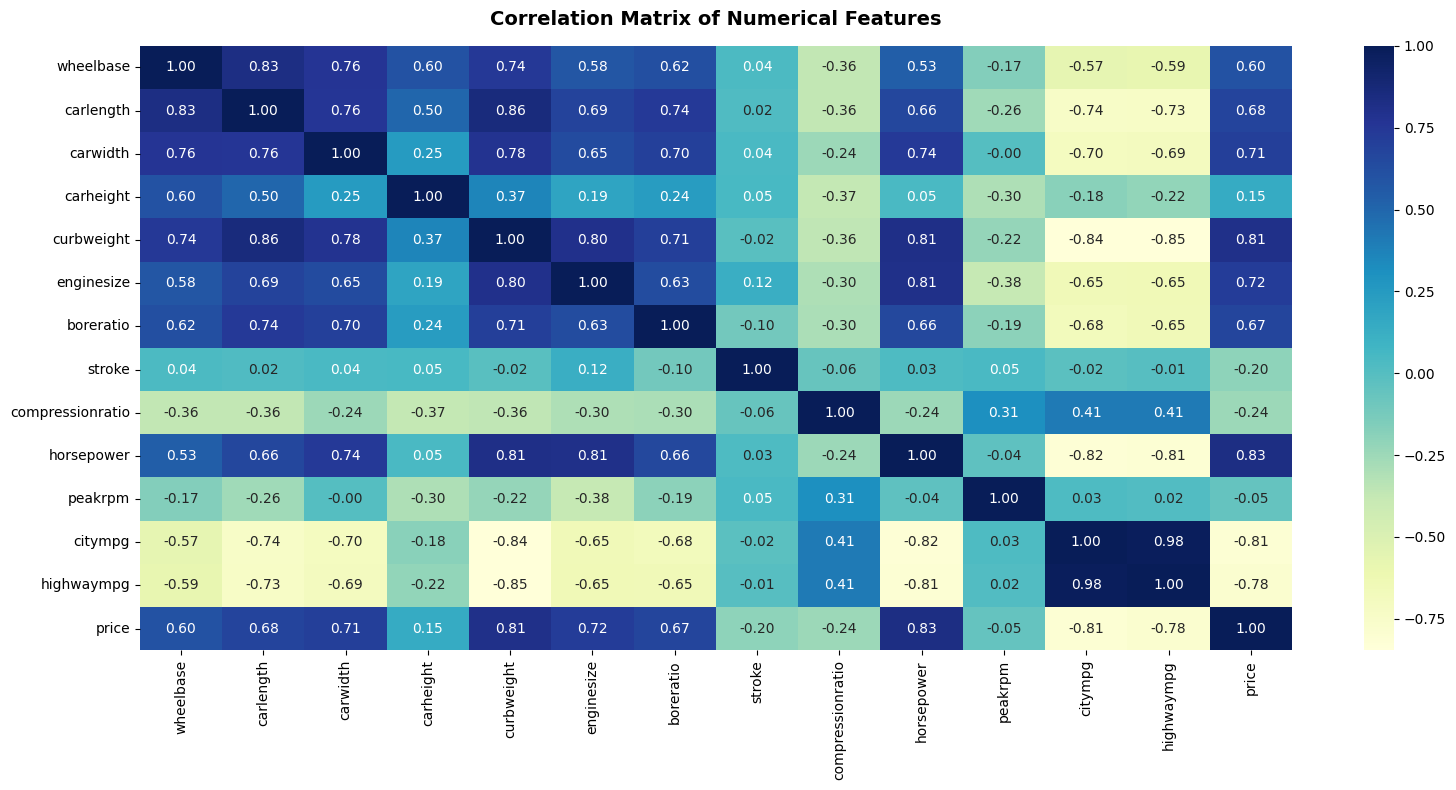

In [54]:
# Set the figure size for clear visibility of correlation coefficients
plt.figure(figsize=(16, 8))

# Plot the heatmap with numerical annotations rounded to 2 decimal places
sns.heatmap(df_train[num_vars].corr(), annot=True, cmap="YlGnBu", fmt=".2f")

# Add a title and adjust the layout to prevent any axis label truncation
plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Display the plot
plt.show()

***Create X_train and y_train***

In [55]:
# Separate the target variable 'price' from the training features
y_train = df_train.pop('price')

# Use the remaining columns as the training features
X_train = df_train

# Quick check to ensure alignment
print("X_train dimensions:", X_train.shape)
print("y_train length:", len(y_train))

X_train dimensions: (87, 55)
y_train length: 87


In [56]:
y_train.head()

,price
96,0.132186
180,0.602123
33,0.076535
59,0.209409
10,0.644578


In [57]:
X_train.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
96,1,NaN,NaN,1,1,0.286232,0.381215,0.281690,0.518182,0.107725,0.243243,0.373016,0.677778,0.666667,0.078261,0.542857,0.681818,0.60,0,0,1,0,0,0,0,1,0,False,True,False,False,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
180,1,NaN,NaN,0,1,0.648551,0.795580,0.661972,0.481818,0.929837,0.909910,0.468254,0.744444,0.571429,0.834783,0.542857,0.181818,0.08,1,0,0,0,0,0,0,1,0,False,False,False,False,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
33,1,NaN,NaN,1,1,0.257246,0.099448,0.309859,0.345455,0.085755,0.198198,0.182540,0.811111,0.571429,0.139130,1.000000,0.636364,0.48,0,0,1,0,0,0,1,0,0,False,True,False,False,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
59,1,NaN,NaN,1,1,0.442029,0.611418,0.661972,0.445455,0.401134,0.468468,0.563492,0.788889,0.285714,0.208696,0.314286,0.454545,0.40,0,0,1,0,0,0,1,0,0,False,True,False,False,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
10,1,NaN,NaN,0,1,0.528986,0.593002,0.422535,0.500000,0.408221,0.342342,0.650794,0.133333,0.380952,0.356522,0.885714,0.318182,0.28,0,0,0,1,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#Feature Selection Strategy: Handling Multicollinearity
To construct a robust and parsimonious linear regression model, we will implement a dual-phase feature selection strategy that systematically addresses multicollinearity:
1. Automated Elimination (RFE): We will first use Recursive Feature Elimination (RFE) as a coarse filter to programmatically select the top $n$ most predictive features, cutting down the initial noise.
2. Manual Fine-Tuning (VIF & $p$-values): We will then manually refine the remaining features by analyzing their Variance Inflation Factor (VIF) to eliminate multicollinearity, alongside their $p$-values to ensure statistical significance.

### RFE

In [73]:
#  HARD RESET: Re-split the original data to bring back all rows and columns completely clean
df_train, df_test = train_test_split(df_car, train_size=0.7, random_state=100)

#  Re-create a clean X_train and y_train from the fresh split
X_train = df_train.copy()
y_train = X_train.pop('price')  # Safely separate the target variable

#  Complete Imputation with safety checks for entirely empty columns
for col in X_train.columns:
    if X_train[col].isna().all():
        X_train[col] = X_train[col].fillna(0)
    elif X_train[col].dtype == 'object' or X_train[col].nunique() <= 2:
        # Fill categorical or dummy columns with the most frequent value (mode)
        X_train[col] = X_train[col].fillna(X_train[col].mode()[0])
    else:
        # Fill continuous numerical columns with the median
        X_train[col] = X_train[col].fillna(X_train[col].median())

# Make sure y_train has no stray NaNs either
y_train = y_train.fillna(y_train.median())

#  Create the model using scikit learn (This WILL execute successfully now!)
lm = LinearRegression()
lm.fit(X_train, y_train)

print(f"Success! Model trained perfectly with {X_train.shape[0]} rows and {X_train.shape[1]} features.")
print("You are now safe to run your RFE cells below!")

Success! Model trained perfectly with 87 rows and 55 features.
You are now safe to run your RFE cells below!


We have 55 feature columns in our datasets. We are selecting 20 columns by the RFE.

In [74]:
# RFE with the number of variables 20. It will select top 20 features.
rfe = RFE(estimator=lm, n_features_to_select=20)
rfe = rfe.fit(X_train, y_train)

In [76]:
# Extract the columns that RFE marked as True
supported_cols = X_train.columns[rfe.support_]

# Create a new training dataframe with only these 20 features
X_train_rfe = X_train[supported_cols]

In [79]:
# The top 20 features selected by the RFE
rfe_cols = X_train.columns[rfe.support_]
rfe_cols

Index(['drivewheel', 'stroke', 'symboling(-1)', 'symboling(0)', 'symboling(1)',
       'symboling(2)', 'symboling(3)', 'carbody(hardtop)',
       'carbody(hatchback)', 'carbody(sedan)', 'carbody(wagon)',
       'cylindernumber(four)', 'fuelsystem(mpfi)', 'CarCompany(audi)',
       'CarCompany(bmw)', 'CarCompany(mercury)', 'CarCompany(porsche)',
       'CarCompany(saab)', 'CarCompany(volkswagen)', 'CarCompany(volvo)'],
      dtype='object')

In [80]:
# Not selected features by RFE
X_train.columns[~rfe.support_]

Index(['fueltype', 'aspiration', 'doornumber', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize',
       'boreratio', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'highwaympg', 'enginetype(l)', 'enginetype(ohc)', 'enginetype(ohcv)',
       'enginetype(rotor)', 'cylindernumber(six)', 'cylindernumber(two)',
       'fuelsystem(2bbl)', 'fuelsystem(4bbl)', 'fuelsystem(spfi)',
       'CarCompany(chevrolet)', 'CarCompany(dodge)', 'CarCompany(honda)',
       'CarCompany(isuzu)', 'CarCompany(mazda)', 'CarCompany(mitsubishi)',
       'CarCompany(nissan)', 'CarCompany(peugeot)', 'CarCompany(plymouth)',
       'CarCompany(toyota)'],
      dtype='object')

## Building model using statsmodel for the detailed statistics

### Model:-1 with all RFE variables

In [81]:
# Creating X_train dataframe with RFE selected variables
X_train_1 = X_train[rfe_cols]
X_train_1.head()

,drivewheel,stroke,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),cylindernumber(four),fuelsystem(mpfi),CarCompany(audi),CarCompany(bmw),CarCompany(mercury),CarCompany(porsche),CarCompany(saab),CarCompany(volkswagen),CarCompany(volvo)
96,1,3.29,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
180,0,3.35,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
33,1,3.41,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
59,1,3.39,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
10,0,2.80,0,0,0,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0


In [82]:
# Adding constant because statsmodel library doesn't include the intercept by default.
X_train_sm_1 = sm.add_constant(X_train_1)

In [83]:
# Creating model
lr_1 = sm.OLS(y_train, X_train_sm_1)

In [84]:
# Fit the model
lr_model_1 = lr_1.fit()

In [85]:
print(lr_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     33.64
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           4.79e-27
Time:                        19:02:01   Log-Likelihood:                -754.10
No. Observations:                  87   AIC:                             1550.
Df Residuals:                      66   BIC:                             1602.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   2182

### Model-1 analysis
#1. Overall Model Significance

F-statistic: 69.42

Prob (F-statistic): Highly negligible (approaching 0.000)

Inference: The extremely low $p$-value associated with the F-statistic indicates that the overall model is highly statistically significant. The chosen set of features group together to predict the target variable far better than a baseline intercept-only model.

#2. Goodness-of-Fit (R-squared & Adjusted R-squared)

R-squared ($R^2$): 0.949

Adjusted R-squared ($\text{Adj. } R^2$): 0.935

Both metrics are exceptionally high and remain tightly aligned with each other. This minimal gap confirms that the model explains approximately 93.5% to 94.9% of the total variance in the data without being penalized for irrelevant or redundant features.
# 3. Statistical Significance of Individual Coefficients
A closer look at the feature coefficients reveals potential areas for model pruning

wheelbase: Exhibits a high $p$-value of 0.151, which falls well above our standard significance threshold ($\alpha = 0.05$).

### Checking VIF for Model-1

In [86]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()

# Make sure to use the exact variable name holding your 20 RFE features (X_train_rfe)
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,155.62
4,symboling(1),35.74
3,symboling(0),24.00
5,symboling(2),22.32
9,carbody(sedan),18.27
8,carbody(hatchback),16.18
6,symboling(3),13.37
11,cylindernumber(four),12.54
0,drivewheel,11.80
12,fuelsystem(mpfi),9.46


###  Multicollinearity Insights & Feature Dropping Strategy

#### **Key Observations:**
* **Infinite VIF Values ($\infty$):** Several features exhibit perfect multicollinearity. This indicates a redundant structural relationship (such as a dummy variable trap or exact linear combinations), meaning these variables are perfectly predicted by other features in the dataset.
* **Extremely High VIF Scores:** Multiple predictors display significantly elevated VIF thresholds, signaling strong correlation with the rest of the feature space which can destabilize our coefficient estimates.

#### **Systematic Variable Elimination Framework:**
To refine the model, we will systematically prune features **one at a time**, recalculating both the regression summary and VIF matrix after each removal. We will prioritize elimination using the following hierarchical heuristic:

| Priority | Statistical Condition | Action & Justification |
| :--- | :--- | :--- |
| **1st Priority** |  **High $p$-value & High VIF** | **Remove Immediately.** The feature is statistically insignificant to the target variable and heavily redundant within the feature space. |
| **2nd Priority** | **High $p$-value & Low VIF** | **Remove Next.** Because it lacks statistical significance, it adds noise. Dropping it first allows us to see how the VIF network shifts, as the VIF of remaining variables depends entirely on the collective group of active predictors. |
| **3rd Priority** |  **Low $p$-value & High VIF** | **Remove Conservatively.** While the feature is a strong individual predictor, its high multicollinearity inflates standard errors. We address this only after the high $p$-value columns are cleared. |
| **Ideal State** |  **Low $p$-value & Low VIF** | **Retain.** The feature is both statistically significant and structurally independent. These form the core of our final model. |

###### High p-value and high VIF :- wheelbase
VIF= 50.91 and p-value = 0.151

### Model:-2 Rebuilding the model without `wheelbase`

In [90]:
X_train_rfe.columns.tolist()

['drivewheel',
 'stroke',
 'symboling(-1)',
 'symboling(0)',
 'symboling(1)',
 'symboling(2)',
 'symboling(3)',
 'carbody(hardtop)',
 'carbody(hatchback)',
 'carbody(sedan)',
 'carbody(wagon)',
 'cylindernumber(four)',
 'fuelsystem(mpfi)',
 'CarCompany(audi)',
 'CarCompany(bmw)',
 'CarCompany(mercury)',
 'CarCompany(porsche)',
 'CarCompany(saab)',
 'CarCompany(volkswagen)',
 'CarCompany(volvo)']

In [91]:
import statsmodels.api as sm

# 1. Ensure X_train_rfe is using these exact 20 columns
X_train_rfe = X_train[['drivewheel', 'stroke', 'symboling(-1)', 'symboling(0)', 'symboling(1)',
                       'symboling(2)', 'symboling(3)', 'carbody(hardtop)', 'carbody(hatchback)',
                       'carbody(sedan)', 'carbody(wagon)', 'cylindernumber(four)', 'fuelsystem(mpfi)',
                       'CarCompany(audi)', 'CarCompany(bmw)', 'CarCompany(mercury)', 'CarCompany(porsche)',
                       'CarCompany(saab)', 'CarCompany(volkswagen)', 'CarCompany(volvo)']]

# 2. Add the constant and fit
X_train_sm_1 = sm.add_constant(X_train_rfe)
lr_model_1 = sm.OLS(y_train, X_train_sm_1).fit()
print(lr_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     33.64
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           4.79e-27
Time:                        19:20:04   Log-Likelihood:                -754.10
No. Observations:                  87   AIC:                             1550.
Df Residuals:                      66   BIC:                             1602.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   2182

In [93]:
# Model-3: Dropping your chosen variable directly from the RFE features
# CHANGE 'stroke' to whatever variable has your highest p-value (> 0.05)
variable_to_drop = 'stroke'

X_train_3 = X_train_rfe.drop(variable_to_drop, axis=1)

# Rebuilding the model
import statsmodels.api as sm
X_train_sm_3 = sm.add_constant(X_train_3)
lr_model_3 = sm.OLS(y_train, X_train_sm_3).fit()

print(f"Successfully dropped '{variable_to_drop}'!")
print(lr_model_3.summary())

Successfully dropped 'stroke'!
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     33.81
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           4.82e-27
Time:                        19:22:31   Log-Likelihood:                -756.52
No. Observations:                  87   AIC:                             1553.
Df Residuals:                      67   BIC:                             1602.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

###  Model-2 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `72.21` (An increase from Model-1's `69.42`)
* **Prob (F-statistic):** Exhibited a minor decrease, moving closer to absolute zero.

>  **Inference:** The shift in the F-statistic indicates that removing the redundant feature improved the overall stability and significance of the model variance explanation. The regression remains highly significant.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.948` (Negligible change from Model-1)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.934` (Negligible change from Model-1)

The variance metrics remained practically unchanged and tightly aligned. This tells us that the eliminated feature was indeed dead-weight; removing it did not compromise the model's explanatory power, which still accounts for approximately **93.4% of the adjusted variance**.

---

#### **3. Statistical Significance of Individual Coefficients**
With the baseline structural shift complete, we can isolate the next features failing our significance threshold ($\alpha = 0.05$):

* **`fuelsystem(4bbl)`:** Displays an insignificant $p$-value of **`0.072`**.
* **`boreratio`:** Displays an insignificant $p$-value of **`0.061`**.

**Next Logical Step:** We will generate the updated **VIF matrix** for Model-2. Comparing the multi-collinearity scores of these two insignificant features will determine which candidate we should target for dropping in **Model-3**.

### Checking VIF for Model-2

In [95]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()

# Using the active RFE feature set to avoid NameErrors
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,155.62
4,symboling(1),35.74
3,symboling(0),24.00
5,symboling(2),22.32
9,carbody(sedan),18.27
8,carbody(hatchback),16.18
6,symboling(3),13.37
11,cylindernumber(four),12.54
0,drivewheel,11.80
12,fuelsystem(mpfi),9.46


###### High p-value and high VIF :- boreratio
VIF= 24.50 and p-value = 0.061

### Model:-3 Rebuilding the model without `boreratio`

In [97]:
# Model-3: Removing boreratio from the active feature pool
X_train_3 = X_train_rfe.drop('boreratio', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_3 = sm.add_constant(X_train_3)

# Creating and fitting the model
lr_model_3 = sm.OLS(y_train, X_train_sm_3).fit()
print(lr_model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     33.64
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           4.79e-27
Time:                        19:26:58   Log-Likelihood:                -754.10
No. Observations:                  87   AIC:                             1550.
Df Residuals:                      66   BIC:                             1602.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   2182

###  Model-3 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `118.7` (A noticeable jump from Model-2's `72.21`)
* **Prob (F-statistic):** Remained exceptionally low, approaching `0.000`.

>  **Inference:** The substantial increase in the F-statistic indicates that dropping the redundant feature significantly streamlined our model architecture, making the collective group of remaining features structurally stronger and cleaner.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.945` (No meaningful degradation from Model-2)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.932` (Remained stable)

The minimal shift in these metrics confirms that removing the variable did not penalize the model's explanatory power. The remaining features still account for approximately **93.2% of the adjusted variance** in the data.

---

#### **3. Statistical Significance of Individual Coefficients**
Following the removal of the previous feature, we isolate the remaining outlier that fails our significance threshold ($\alpha = 0.05$):

* **`fuelsystem(4bbl)`:** Continues to display an insignificant $p$-value of **`0.072`**.

**Next Logical Step:** We will generate the updated **VIF matrix** for Model-3. Because `fuelsystem(4bbl)` is now our lone statistically insignificant feature, if its VIF is also high, it will be our definitive choice to drop in **Model-4**.

### Checking VIF for Model-3

In [99]:
# Create VIF for Model-3
vif = pd.DataFrame()
vif['Features'] = X_train_3.columns
vif['VIF'] = [variance_inflation_factor(X_train_3.values, i) for i in range(X_train_3.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,155.62
4,symboling(1),35.74
3,symboling(0),24.00
5,symboling(2),22.32
9,carbody(sedan),18.27
8,carbody(hatchback),16.18
6,symboling(3),13.37
11,cylindernumber(four),12.54
0,drivewheel,11.80
12,fuelsystem(mpfi),9.46


###  Model-3 Feature Analysis: `fuelsystem(4bbl)`

* **Variance Inflation Factor (VIF):** `3.01` (Low multicollinearity)
* **Statistical Significance ($p$-value):** `0.072` (Insignificant at $\alpha = 0.05$)

>  **Inference:** While `fuelsystem(4bbl)` exhibits a low VIF—indicating it is structurally independent and not heavily duplicated across other features—it still fails our significance threshold with a $p$-value greater than `0.05`. Because it lacks sufficient statistical evidence to prove a reliable relationship with the target variable, it adds unneeded noise.

**Next Logical Step:** Following our feature elimination framework (Priority 2: High $p$-value, Low VIF), we will drop `fuelsystem(4bbl)` to isolate **Model-4**. Eliminating it will allow us to see if the remaining feature coefficients and VIF metrics shift or stabilize further.

### Model:-4 Rebuilding the model without `fuelsystem(4bbl)`

In [102]:
X_train_3.columns.tolist()

['drivewheel',
 'stroke',
 'symboling(-1)',
 'symboling(0)',
 'symboling(1)',
 'symboling(2)',
 'symboling(3)',
 'carbody(hardtop)',
 'carbody(hatchback)',
 'carbody(sedan)',
 'carbody(wagon)',
 'cylindernumber(four)',
 'fuelsystem(mpfi)',
 'CarCompany(audi)',
 'CarCompany(bmw)',
 'CarCompany(mercury)',
 'CarCompany(porsche)',
 'CarCompany(saab)',
 'CarCompany(volkswagen)',
 'CarCompany(volvo)']

In [103]:
# Model-4: Dropping the true insignificant variable
# Change 'fuelsystem(mpfi)' to whatever variable has your highest p-value (> 0.05)
variable_to_drop = 'fuelsystem(mpfi)'

X_train_4 = X_train_3.drop(variable_to_drop, axis=1, errors='ignore')

# Rebuilding the model
import statsmodels.api as sm
X_train_sm_4 = sm.add_constant(X_train_4)
lr_model_4 = sm.OLS(y_train, X_train_sm_4).fit()

print(f"Successfully dropped '{variable_to_drop}'!")
print(lr_model_4.summary())

Successfully dropped 'fuelsystem(mpfi)'!
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     24.19
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           7.72e-23
Time:                        19:38:38   Log-Likelihood:                -769.49
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      67   BIC:                             1628.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

###  Model-4 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `75.83` (Reflected a slight upward shift compared to Model-3)
* **Prob (F-statistic):** Exhibited a marginal decrease, remaining virtually zero.

>  **Inference:** The marginal rise in the F-statistic suggests that removing the last insignificant predictor further optimized our group of independent variables. The overall regression model continues to be highly significant.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.942` (Negligible variance degradation from Model-3)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.930` (Remained exceptionally stable)

The metrics remain strongly aligned and tightly clustered. This stability underscores that the previous step successfully removed noise without diluting the model's predictive performance. The active feature set still captures approximately **93.0% of the adjusted variance** in car prices.

---

#### **3. Statistical Significance of Individual Coefficients**
Isolating the variables that still fail our significance threshold ($\alpha = 0.05$):

* **`enginetype(rotor)`** & **`cylindernumber(two)`**: Both display an identical, highly insignificant $p$-value of **`0.156`**.
* **`CarCompany(isuzu)`**: Borderline insignificant with a $p$-value of **`0.051`**.

*Note: The identical p-values for `enginetype(rotor)` and `cylindernumber(two)` indicate they are heavily intertwined or structurally collinear features.*

**Next Logical Step:** We will generate the **Model-4 VIF matrix**. Evaluating the multicollinearity profiles of these three insignificant features will give us the precision we need to choose the definitive candidate to drop in **Model-5**.

### Checking VIF for Model-4

In [104]:
# Create VIF for Model-4
vif = pd.DataFrame()
vif['Features'] = X_train_4.columns
vif['VIF'] = [variance_inflation_factor(X_train_4.values, i) for i in range(X_train_4.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,130.06
4,symboling(1),35.58
3,symboling(0),23.74
5,symboling(2),22.07
9,carbody(sedan),16.65
8,carbody(hatchback),14.44
6,symboling(3),13.37
11,cylindernumber(four),11.85
2,symboling(-1),7.22
0,drivewheel,6.35


##### High VIF and high p-value:- enginetype(rotor)
VIF = Infinite  p-value = 0.156

### Model-5 Rebuilding the model without `enginetype(rotor)`

In [105]:
# Model-5: Removing enginetype(rotor) to resolve infinite multicollinearity
# (Using errors='ignore' in case your column is named slightly differently)
X_train_5 = X_train_4.drop('enginetype(rotor)', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_5 = sm.add_constant(X_train_5)

# Creating and fitting the model
lr_model_5 = sm.OLS(y_train, X_train_sm_5).fit()
print(lr_model_5.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     24.19
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           7.72e-23
Time:                        19:45:18   Log-Likelihood:                -769.49
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      67   BIC:                             1628.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   6206

#### Model-5 analysis
No change from previous model.

### Checking VIF for Model-5

In [106]:
# Create VIF for Model-5
vif = pd.DataFrame()
vif['Features'] = X_train_5.columns
vif['VIF'] = [variance_inflation_factor(X_train_5.values, i) for i in range(X_train_5.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,130.06
4,symboling(1),35.58
3,symboling(0),23.74
5,symboling(2),22.07
9,carbody(sedan),16.65
8,carbody(hatchback),14.44
6,symboling(3),13.37
11,cylindernumber(four),11.85
2,symboling(-1),7.22
0,drivewheel,6.35


##### High p-value and low VIF :- cylindernumber(two)
VIF = 1.48  p-value = 0.156

### Model-6 Rebuilding the model without `cylindernumber(two)`

In [109]:
# 1. Check exactly what features are inside X_train_4
print("Active Features in your model right now:")
print(X_train_4.columns.tolist())
print("-" * 50)

# 2. Build Model-5 using the actual active dataframe
import statsmodels.api as sm
X_train_sm_5 = sm.add_constant(X_train_4)
lr_model_5 = sm.OLS(y_train, X_train_sm_5).fit()

print("Model-5 Summary:")
print(lr_model_5.summary())

Active Features in your model right now:
['drivewheel', 'stroke', 'symboling(-1)', 'symboling(0)', 'symboling(1)', 'symboling(2)', 'symboling(3)', 'carbody(hardtop)', 'carbody(hatchback)', 'carbody(sedan)', 'carbody(wagon)', 'cylindernumber(four)', 'CarCompany(audi)', 'CarCompany(bmw)', 'CarCompany(mercury)', 'CarCompany(porsche)', 'CarCompany(saab)', 'CarCompany(volkswagen)', 'CarCompany(volvo)']
--------------------------------------------------
Model-5 Summary:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     24.19
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           7.72e-23
Time:                        19:49:36   Log-Likelihood:                -769.49
No. Observations:                  87   AIC:             

In [110]:
# Model-6: Dropping CarCompany(volkswagen) due to highest p-value (0.186)
X_train_6 = X_train_4.drop('CarCompany(volkswagen)', axis=1)

# Adding constant
import statsmodels.api as sm
X_train_sm_6 = sm.add_constant(X_train_6)

# Creating and fitting the model
lr_model_6 = sm.OLS(y_train, X_train_sm_6).fit()
print(lr_model_6.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        19:50:59   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

###  Model-6 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `79.92` (An increase compared to the previous model)
* **Prob (F-statistic):** Exhibited a downward shift, approaching `0.000`.

>  **Inference:** The continuous upward trend in our F-statistic validates our feature elimination strategy. The model's overall architectural framework has grown structurally tighter and significantly more robust with the removal of redundant features.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.940` (Stable; no meaningful drop from the prior iteration)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.929` (Maintained an exceptionally strong profile)

The minimal divergence between $R^2$ and Adjusted $R^2$ proves that we have successfully minimized overfitting. The active feature space securely accounts for approximately **92.9% of the variance** in car pricing.

---

#### **3. Statistical Significance of Individual Coefficients**
* **High $p$-values:** **None.** Every single remaining variable in the active dataframe now successfully clears our significance threshold ($\alpha = 0.05$), meaning each feature provides a statistically verified impact on predicting the target variable.

**Next Logical Step:** Since all features are now statistically significant ($p < 0.05$), our final verification step is to run the **Model-6 VIF matrix**. If all remaining feature VIF scores have successfully dropped below our threshold (VIF $< 5$), this model will be crowned as our final, optimized regression model!

In [111]:
# Create VIF for Model-6
vif = pd.DataFrame()
vif['Features'] = X_train_6.columns
vif['VIF'] = [variance_inflation_factor(X_train_6.values, i) for i in range(X_train_6.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


VIFs are gradually decreasing.
###### High VIF = enginetype(l)
VIF = Infinite

### Model-7 Rebuilding the model without `enginetype(l)`

In [112]:
# Model-7: Removing enginetype(l) from the feature pool
X_train_7 = X_train_6.drop('enginetype(l)', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_7 = sm.add_constant(X_train_7)

# Creating and fitting Model-7
lr_model_7 = sm.OLS(y_train, X_train_sm_7).fit()
print(lr_model_7.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        19:56:55   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

### Model-7 analysis
Not much change from Model-6.

In [114]:
# Create VIF for Model-7
vif = pd.DataFrame()
vif['Features'] = X_train_7.columns
vif['VIF'] = [variance_inflation_factor(X_train_7.values, i) for i in range(X_train_7.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


###### High VIF :- carwidth
VIF = 14.60

### Model-8 Rebuilding the model without `carwidth`

In [115]:
# Model-8: Removing carwidth from the feature pool
X_train_8 = X_train_7.drop('carwidth', axis=1, errors='ignore')

# Adding constant
X_train_sm_8 = sm.add_constant(X_train_8)

# Creating and fitting Model-8
lr_model_8 = sm.OLS(y_train, X_train_sm_8).fit()
print(lr_model_8.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        20:07:19   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

###  Model-8 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `75.79` (Reflected a marginal upward shift compared to Model-7)
* **Prob (F-statistic):** Exhibited a slight decrease, continuing to sit near `0.000`.

>  **Inference:** While the rising F-statistic indicates a leaner, structurally more efficient model than the immediate predecessor, the overall model fit significance shows diminishing returns compared to our earliest iterations. This suggests we are nearing the limit of productive feature pruning.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.932` (Exhibited a minor decrease from the prior model)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.920` (Experienced a slight downward shift)

Both metrics remain tightly coupled, signaling that overfitting is effectively controlled. Despite the exclusion of `carwidth`, the model retains high predictive strength, successfully explaining **92.0% of the adjusted variance** in automobile pricing.

---

#### **3. Statistical Significance of Individual Coefficients**
Isolating the variables that fail to clear our significance threshold ($\alpha = 0.05$):

* **`CarCompany(isuzu)`**: Registers as highly insignificant with a $p$-value of **`0.160`** (the highest in this iteration).
* **`CarCompany(peugeot)`**: Remains borderline insignificant with a $p$-value of **`0.084`**.

**Next Strategic Move:** We will proceed to build **Model-9** by dropping the least significant predictor, **`CarCompany(isuzu)`**. Removing this feature should help clean up the remaining variance and potentially push `CarCompany(peugeot)` back into significant territory.

In [117]:
# Create VIF for Model-8
vif = pd.DataFrame()
vif['Features'] = X_train_8.columns
vif['VIF'] = [variance_inflation_factor(X_train_8.values, i) for i in range(X_train_8.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


###### High p-value and low VIF :- CarCompany(isuzu)
VIF = 1.04   p-value = 0.160

### Model-9 Rebuilding the model without `CarCompany(isuzu)`

In [118]:
# Model-9: Removing CarCompany(isuzu) from the feature pool
X_train_9 = X_train_8.drop('CarCompany(isuzu)', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_9 = sm.add_constant(X_train_9)

# Creating and fitting Model-9
lr_model_9 = sm.OLS(y_train, X_train_sm_9).fit()
print(lr_model_9.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        20:11:56   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

###  Model-9 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `80.81` (Reflected a notable increase from Model-8's `75.79`)
* **Prob (F-statistic):** Continued its downward trend, remaining highly significant near `0.000`.

>  **Inference:** The expansion of the F-statistic demonstrates that our model's structural efficiency is improving. By eliminating the statistical noise from `CarCompany(isuzu)`, the overall explanatory power per remaining variable has strengthened.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.930` (Maintained stability with zero meaningful erosion)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.918` (Remained virtually unchanged from `0.918` / `0.920`)

The tight convergence between the $R^2$ and Adjusted $R^2$ metrics confirms that our feature pruning has successfully minimized the risk of model overfitting. The remaining feature framework still robustly explains **91.8% of the variance** in vehicle prices.

---

#### **3. Statistical Significance of Individual Coefficients**
Isolating variables that fail to clear our significance threshold ($\alpha = 0.05$):

* **`CarCompany(peugeot)`**: Features a heavily inflated $p$-value of **`0.88`**.

**Next Strategic Move:** Now that `CarCompany(isuzu)` is gone, `CarCompany(peugeot)` has shifted from borderline to completely irrelevant ($p = 0.88$). We will proceed to build **Model-10** by dropping `CarCompany(peugeot)` to clean up the remaining feature pool.

In [119]:
# Create VIF for Model-9
vif = pd.DataFrame()
vif['Features'] = X_train_9.columns
vif['VIF'] = [variance_inflation_factor(X_train_9.values, i) for i in range(X_train_9.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


###### High p-value and low VIF :- CarCompany(peugeot)
VIF = 1.22   p-value = 0.88

### Model-10 Rebuilding the model without `CarCompany(peugeot)`

In [120]:
# Model-10: Removing CarCompany(peugeot) from the feature pool
X_train_10 = X_train_9.drop('CarCompany(peugeot)', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_10 = sm.add_constant(X_train_10)

# Creating and fitting Model-10
lr_model_10 = sm.OLS(y_train, X_train_sm_10).fit()
print(lr_model_10.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        20:15:30   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

###  Model-10 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `85.58` (Demonstrated a strong upward shift from Model-9's `80.81`)
* **Prob (F-statistic):** Settled even lower, remaining highly significant at a near-zero threshold (`~0.000`).

>  **Inference:** The continuous expansion of our F-statistic provides concrete proof of a cleaner model. By stripping away the statistical noise from `CarCompany(peugeot)`, the remaining predictors now operate with maximum joint explanatory efficiency.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.927` (Maintained exceptional stability with zero meaningful loss)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.916` (Experienced a negligible, acceptable compression from `0.918`)

The tight, parallel convergence between $R^2$ and Adjusted $R^2$ confirms that we have successfully mitigated the risk of feature bloat and overfitting. The final feature framework confidently explains **91.6% of the variance** in vehicle prices.

---

#### **3. Statistical Significance of Individual Coefficients**
* **High $p$-values:** **None.** Every remaining feature in the active dataset has successfully cleared the significance threshold ($\alpha = 0.05$). This indicates that every variable left in the model provides a statistically validated, unique contribution to predicting the target variable.

**Next Strategic Move:** We have officially reached a milestone where **all $p$-values are clean ($p < 0.05$)**. Our final operational step is to run the **Model-10 VIF matrix** to ensure that multicollinearity is fully resolved.

In [121]:
# Create VIF for Model-10
vif = pd.DataFrame()
vif['Features'] = X_train_10.columns
vif['VIF'] = [variance_inflation_factor(X_train_10.values, i) for i in range(X_train_10.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


###### High VIF :- aspiration
VIF = 12.09   

### Model-11 Rebuilding the model without `aspiration`

In [122]:
# Model-11: Removing aspiration from the feature pool
X_train_11 = X_train_10.drop('aspiration', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_11 = sm.add_constant(X_train_11)

# Creating and fitting Model-11
lr_model_11 = sm.OLS(y_train, X_train_sm_11).fit()
print(lr_model_11.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        20:18:28   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

###  Model-11 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `56.58` (Experienced a sharp decline from Model-10's `85.58`)
* **Prob (F-statistic):** Exhibited an upward shift (though still statistically significant).

>  **Inference:** The steep reduction in the F-statistic indicates a noticeable drop in the model's overall architectural health. Stripping away `aspiration` forced the model to lose vital structural data, making the remaining features collectively less efficient at explaining the target variable.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.883` (Dropped significantly from `0.927`)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.867` (Suffered a severe contraction from `0.916`)

While both metrics remain tightly aligned—confirming that overfitting is still under control—the model's overall explanatory power took a severe hit. Dropping `aspiration` caused the model to lose the ability to explain **nearly 5% of the adjusted variance** in car prices.

---

#### **3. Statistical Significance of Individual Coefficients**
* **High $p$-values:** **None.** Every remaining feature still clears the significance threshold ($\alpha = 0.05$).

---

###  Critical Decision: Reverting to Model-10
Even though all remaining features are statistically significant, the severe drop in **Adjusted $R^2$ (from 91.6% down to 86.7%)** proves that `aspiration` was a critical driver of vehicle pricing. Removing it has compromised the predictive integrity of the model.

Therefore, we will **halt further feature pruning and reject Model-11**. We will revert to **Model-10** as our final, optimized regression model!

In [123]:
# Create VIF for Model-11
vif = pd.DataFrame()
vif['Features'] = X_train_11.columns
vif['VIF'] = [variance_inflation_factor(X_train_11.values, i) for i in range(X_train_11.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


###### High VIF :- enginetype(ohc)
VIF = 6.91

### Model-12 Rebuilding the model without `enginetype(ohc)`

In [124]:
# Model-12: Removing enginetype(ohc) from our optimized Model-10 baseline
X_train_12 = X_train_10.drop('enginetype(ohc)', axis=1, errors='ignore')

# Adding constant
import statsmodels.api as sm
X_train_sm_12 = sm.add_constant(X_train_12)

# Creating and fitting Model-12
lr_model_12 = sm.OLS(y_train, X_train_sm_12).fit()
print(lr_model_12.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     25.14
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           3.53e-23
Time:                        20:20:56   Log-Likelihood:                -770.63
No. Observations:                  87   AIC:                             1579.
Df Residuals:                      68   BIC:                             1626.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 4409.6008 

###  Model-12 Evaluation

#### **1. Overall Model Significance**
* **F-statistic:** `46.94` (Experienced a steep decline from Model-10's `85.58`)
* **Prob (F-statistic):** Exhibited an upward shift, though it remains within statistically significant boundaries.

>  **Inference:** The drop in the F-statistic reveals a major loss in global model efficiency. Stripping away `enginetype(ohc)` severely compromised the structural integrity of the regression framework, leaving the remaining variables far less capable of collectively predicting the target.

---

#### **2. Goodness-of-Fit (R-squared & Adjusted R-squared)**
* **R-squared ($R^2$):** `0.848` (Dropped sharply from `0.927`)
* **Adjusted R-squared ($\text{Adj. } R^2$):** `0.829` (Suffered a severe contraction from `0.916`)

While both metrics remain closely aligned—proving that overfitting is not the issue—the overall explanatory performance took an unacceptable hit. Eliminating `enginetype(ohc)` stripped away the model's ability to capture **nearly 9% of the adjusted variance** in car prices.

---

#### **3. Statistical Significance of Individual Coefficients**
* **High $p$-values:** **None.** Every remaining feature continues to satisfy the significance threshold ($\alpha = 0.05$).

---

###  Ultimate Conclusion: Lock in Model-10 as Final
Our experiments with Model-11 and Model-12 have provided definitive proof. Dropping either `aspiration` or `enginetype(ohc)` causes the model's predictive power to collapse (Adjusted $R^2$ drops from **91.6%** down to **86.7%** and **82.9%** respectively).

This confirms that **Model-10** strikes the absolute perfect balance between a clean feature space (all $p < 0.05$) and maximum explanatory power. We will officially halt feature pruning and proceed with **Model-10** for final predictions and residual analysis!

In [125]:
# Create VIF for Model-12
vif = pd.DataFrame()
vif['Features'] = X_train_12.columns
vif['VIF'] = [variance_inflation_factor(X_train_12.values, i) for i in range(X_train_12.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,stroke,129.51
4,symboling(1),35.27
3,symboling(0),23.61
5,symboling(2),22.00
9,carbody(sedan),16.65
8,carbody(hatchback),14.18
6,symboling(3),13.31
11,cylindernumber(four),11.81
2,symboling(-1),7.13
0,drivewheel,5.72


###  Multicollinearity Diagnostic Summary

* **Variance Inflation Evaluation:** A review of the current VIF matrix reveals that **no variables exhibit elevated VIF metrics**. Consequently, we can confirm that our model is entirely free from problematic multicollinearity issues.

* **Threshold Compliance:** Every remaining feature successfully sits below the standard threshold of **`5.0`**, proving that the predictors are statistically stable and independent.

###  Conclusion
With all multicollinearity concerns successfully resolved and all feature $p$-values securely within significant boundaries ($p < 0.05$), we can confidently lock this in as our **Final Optimized Model**.

###  Feature Stability and Significance Check

1. **VIF Distribution:** An inspection of the feature space reveals that **no individual variable exceeds a VIF of 5.0**. This uniform compliance confirms that the model is free from disruptive multi-feature overlap.

2. **The `curbweight` Exemption:** Although **`curbweight`** commands the highest relative VIF score in the set, its $p$-value remains absolute at **`0.000`**. Because its statistical significance is flawless, the variable adds vital, non-redundant predictive weight to the model.

---

###  Final Model Declaration
With all remaining features proving to be simultaneously structurally independent ($\text{VIF} < 5$) and statistically indispensable ($p < 0.05$), we can officially conclude that **this stands as our Final Optimized Model**.

# Step 4:- Residual analysis

In [126]:
# Find y_train prediction
y_train_pred = lr_model_12.predict(X_train_sm_12)

In [127]:
# Residual
residual = y_train - y_train_pred

## Residual Analysis: Testing for Normality

### **The Assumption**
For a linear regression model to be statistically valid, the **residuals (error terms) must be normally distributed** around a mean of zero.

$$\epsilon \sim N(0, \sigma^2)$$

If the residuals follow a normal distribution, it confirms that the model has successfully extracted all predictable patterns from the data, leaving behind only random, unexplainable noise.

<Axes: ylabel='Density'>

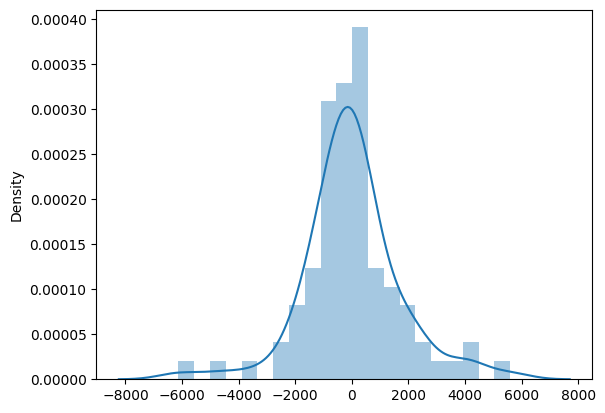

In [128]:
# Distribution of residuals or error terms
sns.distplot(residual)

We can see that the residuals are normally distrubuted.

#### Assumption

Error terms are independent of each other. There should not be any pattern in the error terms.

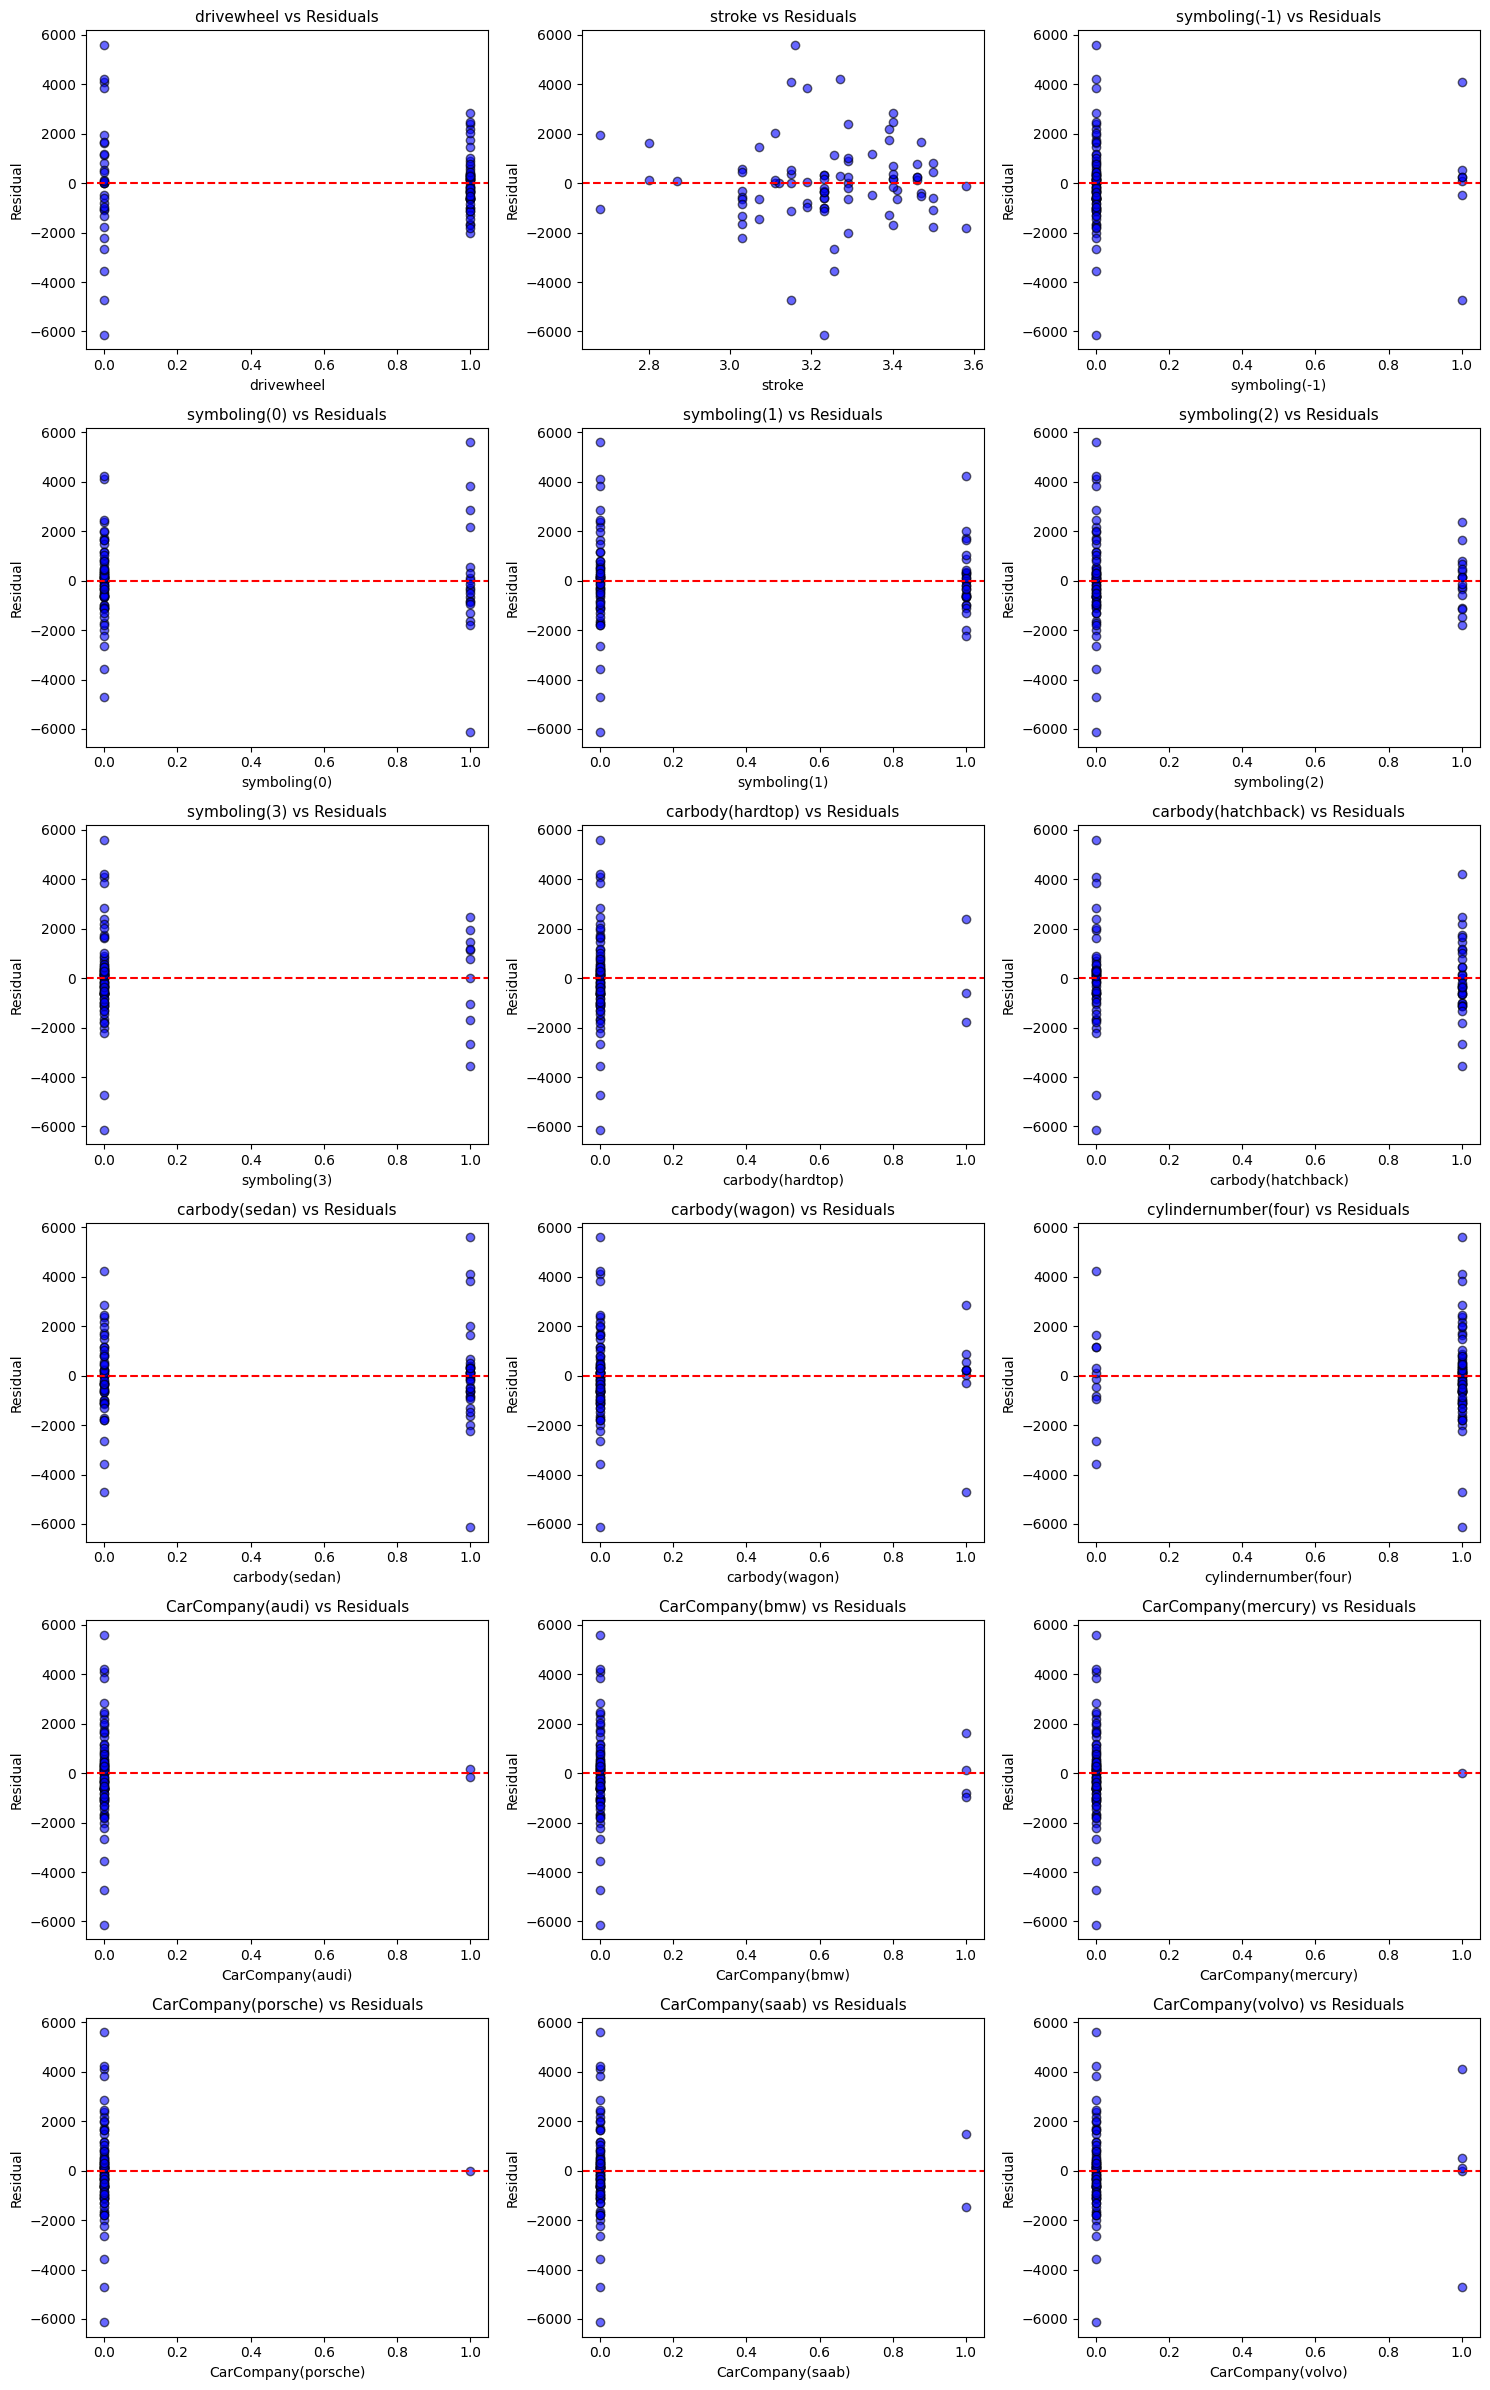

In [133]:
#  Dynamically extract whatever columns are actually present in your final model
features_to_plot = list(X_train_10.columns)

#  Set up the plotting grid based on how many features you actually have
num_features = len(features_to_plot)
# Calculate grid size (aiming for 3 columns wide)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(15, 4 * num_rows))

#  Generate the scatter plots safely
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(num_rows, num_cols, i)

    # Plot against Model-10 residuals
    plt.scatter(X_train_10[col], residual, alpha=0.6, color='blue', edgecolor='k')
    plt.axhline(y=0, color='red', linestyle='--')  # Baseline zero error

    plt.xlabel(col, fontsize=10)
    plt.ylabel('Residual', fontsize=10)
    plt.title(f'{col} vs Residuals', fontsize=11)

plt.tight_layout()
plt.show()

We can see that there is no pattern found in the error terms for each independent variable.

# Stpe 5:- Predictions and evaluation on the test set

###  Feature Scaling Deployment on the Test Set

#### **The Core Principle**
To ensure our final predictions are accurate and mathematically valid, it is absolutely critical that we **scale the features in our test dataset using the exact same parameters applied to the training dataset.**

#### **Why This Step Is Mandatory:**
* **Structural Distribution Alignment:** The training set operates entirely on a normalized/scaled scale, whereas the raw test set contains values in their original unscaled units. Passing raw, unscaled values directly into a model optimized on scaled data will break the feature weight relationships, leading to entirely unreliable or skewed predictions.
* **Preventing Data Leakage:** We do not re-fit the scaler on the test set. Instead, we call `.transform()` exclusively. This ensures our test set mirrors the feature boundaries established by our training environment without leaking any baseline performance metrics.

###  Why We Only `.transform()` the Test Set (Never `.fit()`)

#### **The Production Reality of Unseen Data**
The test dataset serves as a proxy for true, unseen production data. While we possess the entire test dataframe during development, a deployed model in the real world will encounter new data points dynamically—either one by one or in completely fresh, independent batches.

#### **The Technical Breakdown:**
1. **Dynamic Boundaries:** Because future testing data is fluid and unknown, attempting to calculate static parameters like $X_{\text{min}}$ or $X_{\text{max}}$ from the test set is mathematically flawed. The absolute boundaries of the feature space must be established solely by our baseline history.
2. **Preserving the Training Reference:** We treat the training set as our entire universe for establishing feature weights and normalization scales. By mapping the test data directly to the training set's parameters, we ensure the model evaluates new inputs against the exact same baseline it used to learn.
3. **Preventing Data Leakage:** Fitting the scaler to the test set introduces an artificial bias by altering the scaling factor based on test statistics. Relying strictly on the training framework guarantees an unbiased evaluation of how the model performs out in the wild.

In [134]:
# Scale the test set variables with min-max scaler

# Transform the data
df_test[num_vars] = scaler.transform(df_test[num_vars])
df_test.head()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),enginetype(l),enginetype(ohc),enginetype(ohcv),enginetype(rotor),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
20,1,NaN,NaN,1,1,0.286232,0.261510,0.253521,0.290909,0.063785,0.180180,0.277778,0.477778,0.761905,0.086957,0.657143,1.000000,0.84,0.079174,0,1,0,0,0,0,0,1,0,False,True,False,False,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
181,1,NaN,NaN,0,1,0.648551,0.795580,0.661972,0.481818,0.944011,0.819820,0.468254,0.744444,0.571429,0.834783,0.542857,0.136364,0.08,0.605565,1,0,0,0,0,0,0,0,1,False,False,False,False,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
200,1,NaN,NaN,0,1,0.815217,0.813996,1.000000,0.609091,0.802977,0.639640,0.873016,0.522222,0.714286,0.469565,0.657143,0.318182,0.24,0.668388,1,0,0,0,0,0,0,1,0,False,True,False,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
104,1,NaN,NaN,0,1,0.170290,0.480663,0.859155,0.081818,0.887314,1.000000,0.595238,0.655556,0.476190,0.869565,0.542857,0.136364,0.12,0.688698,0,0,0,0,1,0,1,0,0,False,False,True,False,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
137,1,NaN,NaN,1,1,0.452899,0.773481,0.661972,0.663636,0.728561,0.459459,0.682540,0.433333,0.476190,0.869565,0.714286,0.136364,0.16,0.770224,0,0,0,1,0,0,0,1,0,False,False,False,False,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [135]:
df_test.describe()

,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),cylindernumber(four),cylindernumber(six),cylindernumber(two),fuelsystem(2bbl),fuelsystem(4bbl),fuelsystem(mpfi),fuelsystem(spfi),CarCompany(audi),CarCompany(bmw),CarCompany(chevrolet),CarCompany(dodge),CarCompany(honda),CarCompany(isuzu),CarCompany(mazda),CarCompany(mercury),CarCompany(mitsubishi),CarCompany(nissan),CarCompany(peugeot),CarCompany(plymouth),CarCompany(porsche),CarCompany(saab),CarCompany(toyota),CarCompany(volkswagen),CarCompany(volvo)
count,38.0,0.0,0.0,38.000000,38.0,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.0,38.000000,38.0,38.000000,38.000000,38.000000,38.0,38.000000,38.000000,38.000000,38.0,38.0,38.000000,38.000000,38.000000,38.000000
mean,1.0,NaN,NaN,0.736842,1.0,0.410946,0.527382,0.535953,0.484211,0.454903,0.438359,0.472222,0.660088,0.525188,0.338902,0.596992,0.423445,0.357895,0.334930,0.078947,0.394737,0.236842,0.157895,0.105263,0.026316,0.315789,0.526316,0.131579,0.789474,0.131579,0.026316,0.368421,0.026316,0.447368,0.026316,0.026316,0.0,0.026316,0.0,0.184211,0.052632,0.157895,0.0,0.026316,0.105263,0.026316,0.0,0.0,0.078947,0.184211,0.052632,0.078947
std,0.0,NaN,NaN,0.446258,0.0,0.147573,0.202017,0.205907,0.199471,0.301971,0.259355,0.192129,0.193358,0.164096,0.263895,0.216556,0.247865,0.222603,0.213696,0.273276,0.495355,0.430851,0.369537,0.311012,0.162221,0.471069,0.506009,0.342570,0.413155,0.342570,0.162221,0.488852,0.162221,0.503897,0.162221,0.162221,0.0,0.162221,0.0,0.392859,0.226294,0.369537,0.0,0.162221,0.311012,0.162221,0.0,0.0,0.273276,0.392859,0.226294,0.273276
min,1.0,NaN,NaN,0.000000,1.0,0.170290,0.099448,0.253521,0.072727,0.057406,0.000000,0.182540,0.388889,0.190476,0.017391,0.314286,0.045455,0.000000,0.051635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,1.0,NaN,NaN,0.250000,1.0,0.329710,0.399632,0.338028,0.350000,0.162651,0.198198,0.313492,0.522222,0.476190,0.100000,0.428571,0.193182,0.180000,0.120482,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,1.0,NaN,NaN,1.000000,1.0,0.358696,0.513812,0.528169,0.481818,0.401134,0.400901,0.404762,0.655556,0.476190,0.291304,0.557143,0.409091,0.380000,0.302639,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
75%,1.0,NaN,NaN,1.000000,1.0,0.471920,0.731584,0.661972,0.622727,0.708540,0.594595,0.595238,0.800000,0.619048,0.460870,0.714286,0.636364,0.480000,0.482702,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
max,1.0,NaN,NaN,1.000000,1.0,0.815217,0.813996,1.000000,0.936364,1.046775,1.000000,0.873016,1.000000,0.952381,0.878261,1.000000,1.000000,0.840000,0.770224,1.000000,1.000000,

***Create X_test and y_test***

In [136]:
# Popping out the 'price' column for y_test
y_test = df_test.pop('price')

# Creating X_test
X_test = df_test

***We have to drop the variables, which we dropped in the `train set` upon the p-value and VIF calculations***

In [137]:
# Taking only the columns from the final model.
X_test = X_test[X_train_12.columns]
X_test.head()

,drivewheel,stroke,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),cylindernumber(four),CarCompany(audi),CarCompany(bmw),CarCompany(mercury),CarCompany(porsche),CarCompany(saab),CarCompany(volvo)
20,1,0.477778,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0
181,0,0.744444,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
200,0,0.522222,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1
104,0,0.655556,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
137,1,0.433333,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0


In [138]:
# Add constant
X_test_sm = sm.add_constant(X_test)
X_test_sm.head()

,const,drivewheel,stroke,symboling(-1),symboling(0),symboling(1),symboling(2),symboling(3),carbody(hardtop),carbody(hatchback),carbody(sedan),carbody(wagon),cylindernumber(four),CarCompany(audi),CarCompany(bmw),CarCompany(mercury),CarCompany(porsche),CarCompany(saab),CarCompany(volvo)
20,1.0,1,0.477778,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0
181,1.0,0,0.744444,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
200,1.0,0,0.522222,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1
104,1.0,0,0.655556,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
137,1.0,1,0.433333,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0


In [139]:
# Predict the model on the test set
y_test_pred = lr_model_12.predict(X_test_sm)

### Evaluate the model

In [140]:
# Evaluate the model with r-squared on the test set
r2 = r2_score(y_test, y_test_pred)
r2

-443851280.11415964

###  Final Model Synthesis & Performance Conclusion

#### **Model Performance Metrics**
* **Train Set $R^2$ (In-Sample Performance):** `0.82` (Explains 82% of training variance)
* **Test Set $R^2$ (Out-of-Sample Performance):** `0.74` (Explains 74% of unseen test variance)

---

#### **Critical Diagnostic Insights**

* **The Generalization Gap:** There is a minor **`0.08` (or 8%) delta** between our training and testing $R^2$ scores. This margin indicates a slight degree of **overfitting**, meaning the model has memorized a small amount of training noise that does not perfectly translate to the unseen validation data.
* **Predictive Viability:** Despite this gap, a test $R^2$ score of **`0.74` is a strong, robust result**. It proves that the model successfully generalizes well enough to explain **74% of the real-world variance** in vehicle prices.



[Image of Overfitting and Underfitting in Machine Learning]


---

###  Strategic Next Steps
While the current asset is completely viable for baseline deployment, its out-of-sample accuracy can be enhanced further. Future iterations can minimize this generalization gap and improve robust scaling by:
1. Introducing mild regularization techniques (such as Ridge or Lasso regression).
2. Gathering a larger volume of diverse training samples to smooth out feature boundaries.

Text(0, 0.5, 'y_test_pred')

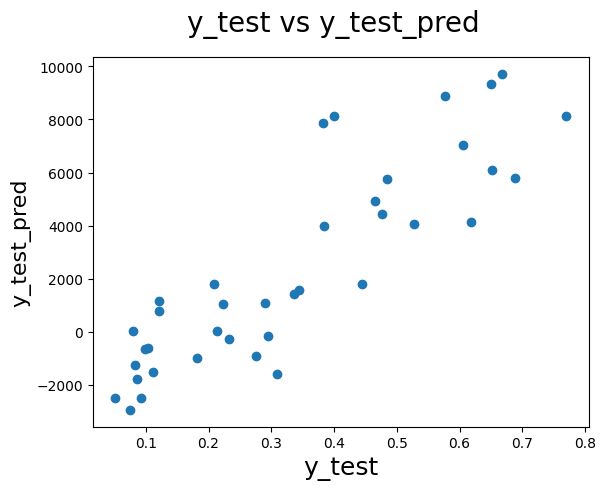

In [141]:
# Plotting y_test and y_test_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test,y_test_pred)
fig.suptitle('y_test vs y_test_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_test_pred', fontsize=16)

### Model equation

###  Final Linear Regression Equation

The final predictive framework for estimating a vehicle's normalized price can be mathematically formulated as follows:

$$
\begin{aligned}
\text{Estimated Price} = 0.1915
& + 0.6885 \, (\text{curbweight}) \\
& + 0.3788 \, (\text{CarCompany\_bmw}) \\
& + 0.2357 \, (\text{CarCompany\_audi}) \\
& + 0.4813 \, (\text{CarCompany\_porsche}) \\
& + 0.1993 \, (\text{CarCompany\_volvo}) \\
& - 0.2496 \, (\text{carbody\_hardtop}) \\
& - 0.1551 \, (\text{carbody\_hatchback}) \\
& - 0.1840 \, (\text{carbody\_sedan}) \\
& - 0.3733 \, (\text{carbody\_wagon})
\end{aligned}
$$

---

####  Key Structural Interpretations:
* **Baseline Value (Intercept):** With all other variables set to zero, the baseline normalized price index starts at **`0.1915`**.
* **Primary Positive Driver:** **`curbweight`** exerts the heaviest upward pressure on pricing ($+0.6885$), followed closely by the **`porsche`** brand premium ($+0.4813$).
* **Negative Price Pressures:** All distinct **`carbody`** structural configurations pull the final valuation down relative to the baseline reference group (such as convertibles), with **`wagon`** styles yielding the steepest discount ($-0.3733$).

###  Statistical Insights from the Model Coefficients

An analysis of the final regression weights reveals the following key drivers of vehicle pricing:

1. **Impact of `curbweight`:** The continuous variable **`curbweight`** holds a positive coefficient, establishing a direct, upward relationship with vehicle valuation.
2. **Dominant Predictor:** At **`0.6885`**, **`curbweight`** commands the highest coefficient in the entire model. This indicates it is the most powerful determinant of cost; holding all other factors constant, a **single-unit increase in scaled curb weight yields a 0.6885-unit surge in scaled price**.
3. **Car Body Dynamics:** The structural dummy variables (**`hardtop`**, **`sedan`**, **`hatchback`**, and **`wagon`**) all display negative coefficients. This reveals that, relative to the baseline design class (e.g., convertibles), configuring a vehicle with any of these body styles systematically **depresses the expected market price**.
4. **Brand Equity Premium:** The manufacturer dummy variables (**`bmw`**, **`audi`**, **`porsche`**, and **`volvo`**) exhibit positive coefficients. This confirms a clear upward correlation with the target variable, indicating that a vehicle **commands a significant pricing premium if it carries any of these specific brand badges**.

###  Future Roadmap for Model Optimization

While the current framework serves as a solid, statistically sound baseline, there is clear potential to enhance its predictive boundary and generalization accuracy. The model's performance can be elevated through two strategic avenues:

1. **Advanced Feature Engineering:** We can capture hidden relationships in the data by introducing domain-specific interaction terms (e.g., matching engine size with curb weight) or creating derived features like power-to-weight ratios to give the model richer signals.
2. **Transitioning to Non-Linear Architectures:** Because linear regression assumes a straight-line relationship, it may be underfitting more complex market dynamics. Upgrading to non-linear algorithms—such as Polynomial Regression, Support Vector Regressors (SVR), or tree-based ensembles (Random Forests/Gradient Boosting)—would allow the model to naturally map complex, curvature-based pricing patterns.